<h1 style="background-color:#9A9786; color:white;">Exámen: Modelación No Supervisada </h1>

**Alumna:** Erika Margarita Villaobos Martínez

**Fecha de entrega:** 22 de febrero 2026

___

<h2 style="background-color:#E8E6D8; color:#595959;">Paso 1: Librerias y lectura de archivos </h2> 

<h2 style="color:#9A9786; font-size: 1.2em; font-weight: bold;"> Librerías </h2>

In [105]:
#General
import numpy as np
import pandas as pd
#from scipy.stats import uniform
#import os
from skimpy import skim
#from tqdm import tqdm

#Graficas
import matplotlib.pyplot as plt
#import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
#from pandas.plotting import andrews_curves

#Valores atipicos
#from pyod.models.mcd import MCD
from pyod.models.iforest import IForest

#Codificadores
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

#Busqueda de hiper-parametros, train test, metricas
#from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score, train_test_split
#from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer

#Modelo de regresión
#from xgboost import XGBRegressor
#from lightgbm import LGBMRegressor
#from sklearn.ensemble import RandomForestRegressor

#Escaladores
from sklearn.preprocessing import RobustScaler

#Reductores
from sklearn.decomposition import PCA

# Clusters
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from yellowbrick.cluster import KElbowVisualizer
from yellowbrick.cluster import SilhouetteVisualizer

<h2 style="color:#9A9786; font-size: 1.2em; font-weight: bold;"> Lectura de archivos </h2>

In [2]:
df=pd.read_csv("../data/incendios_forestales.csv")

In [3]:
df.head()

,anio,Clave_del_incendio,latitud,longitud,Clave_Municipio,Estado,Municipio,CVE_ENT,CVE_MUN,CVEGEO,...,Entidad,fn_Clave_del_incendio,fn_Predio,fn_Causa,fn_Causa_especifica,fn_Duracion_dias,fn_Tipo_de_incendio,fn_Tipo_Vegetacion,fn_Tipo_impacto,fn_Tamano
0,2022,22-01-0001,21.997253,-102.230097,11,Aguascalientes,San Francisco de los Romo,1,11,1101,...,Aguascalientes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2022,22-01-0002,21.694700,-102.265758,1,Aguascalientes,Aguascalientes,1,1,101,...,Aguascalientes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022,22-01-0003,21.686344,-102.274769,1,Aguascalientes,Aguascalientes,1,1,101,...,Aguascalientes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2022,22-01-0004,21.837694,-102.247233,1,Aguascalientes,Aguascalientes,1,1,101,...,Aguascalientes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022,22-01-0005,21.752181,-102.480086,1,Aguascalientes,Aguascalientes,1,1,101,...,Aguascalientes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df.describe()

,anio,latitud,longitud,Clave_Municipio,CVE_ENT,CVE_MUN,CVEGEO,Arbolado_Adulto,Renuevo,Arbustivo,...,Duracion,fn_Clave_del_incendio,fn_Predio,fn_Causa,fn_Causa_especifica,fn_Duracion_dias,fn_Tipo_de_incendio,fn_Tipo_Vegetacion,fn_Tipo_impacto,fn_Tamano
count,22332.000000,22332.000000,22332.000000,22332.000000,22332.000000,22332.000000,22332.000000,22332.000000,22332.000000,22332.000000,...,2.233200e+04,817.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,2023.057451,20.494523,-100.878997,54.995970,14.509404,54.995970,4819.328721,3.771629,2.983198,43.502918,...,1.551827e+05,30677.904529,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.809887,3.052118,4.248621,64.950907,6.344473,64.950907,5645.573317,44.815464,36.957479,314.536013,...,5.459844e+05,11052.662463,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,2022.000000,14.761028,-117.074044,1.000000,1.000000,1.000000,11.000000,0.000000,0.000000,0.000000,...,0.000000e+00,10982.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,2022.000000,19.115856,-103.703721,12.000000,9.000000,12.000000,909.000000,0.000000,0.000000,0.000000,...,1.152000e+04,20995.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,2023.000000,19.568292,-100.032224,34.000000,14.000000,34.000000,2908.000000,0.000000,0.000000,1.000000,...,2.700000e+04,31832.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,2024.000000,20.807371,-98.893567,82.000000,16.000000,82.000000,7216.000000,0.000000,0.000000,10.000000,...,1.395750e+05,40506.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,2024.000000,32.599875,-86.837306,570.000000,32.000000,570.000000,56720.000000,2599.401400,3180.721100,18365.000000,...,6.428160e+07,47476.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<h2 style="background-color:#E8E6D8; color:#595959;">Paso 2: Calidad de datos </h2> 

In [5]:
#Transformamos en categorica
df["Clave_del_incendio"] = df["Clave_del_incendio"].astype("category")
df["Estado"] = df["Estado"].astype("category")
df["Municipio"] = df["Municipio"].astype("category")
df["Region"] = df["Region"].astype("category")
df["Predio"] = df["Predio"].astype("category")
df["Causa"] = df["Causa"].astype("category")
df["Causa_especifica"] = df["Causa_especifica"].astype("category")
df["Fecha_Inicio"] = df["Fecha_Inicio"].astype("category")
df["Fecha_Termino"] = df["Fecha_Termino"].astype("category")
df["Duracion_dias"] = df["Duracion_dias"].astype("category")
df["Tipo_de_incendio"] = df["Tipo_de_incendio"].astype("category")
df["Tipo_Vegetacion"] = df["Tipo_Vegetacion"].astype("category")
df["Regimen_de_fuego"] = df["Regimen_de_fuego"].astype("category")
df["Tipo_impacto"] = df["Tipo_impacto"].astype("category")
df["Tamano"] = df["Tamano"].astype("category")
df["Entidad"] = df["Entidad"].astype("category")
df["fn_Clave_del_incendio"] = df["fn_Clave_del_incendio"].astype("category")

In [6]:
skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types               Categories                                        │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓ ┏━━━━━━━━━━━━━━━━━━━━━━━┓                                │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃ ┃ Categorical Variables ┃                                │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩ ┡━━━━━━━━━━━━━━━━━━━━━━━┩                                │
│ │ Number of rows    │ 22332  │ │ category    │ 17    │ │ Clave_del_incendio    │                                │
│ │ Number of columns │ 41     │ │ float64     │ 16    │ │ Estado                │                                │
│ └───────────────────┴────────┘ │ int32       │ 8     │ │ Municipio             │                                │
│                                └─────────────┴───────┘ │ Region                │                                │
│                                                        │ Predio                │                                │
│                                                        │ Causa                 │                                │
│                                                        │ Causa_especifica      │                                │
│                                                        │ Fecha_Inicio          │                                │
│                                                        │ Fecha_Termino         │                                │
│                                                        │ Duracion_dias         │                                │
│                                                        │ Tipo_de_incendio      │                                │
│                                                        │ Tipo_Vegetacion       │                                │
│                                                        │ Regimen_de_fuego      │                                │
│                                                        │ Tipo_impacto          │                                │
│                                                        │ Tamano                │                                │
│                                                        │ Entidad               │                                │
│                                                        │ fn_Clave_del_incendio │                                │
│                                                        └───────────────────────┘                                │
│                                                    All null                                                     │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓  │
│ ┃ column                                                           ┃ NA                   ┃ NA %             ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩  │
│ │ fn_Predio                                                        │                22332 │              100 │  │
│ │ fn_Causa                                                         │                22332 │              100 │  │
│ │ fn_Causa_especifica                                              │                22332 │              100 │  │
│ │ fn_Duracion_dias                                                 │                22332 │              100 │  │
│ │ fn_Tipo_de_incendio                                              │                22332 │              100 │  │
│ │ fn_Tipo_Vegetacion                                               │                22332 │              100 │  │
│ │ fn_Tipo_impacto                                                  │                22332 │              100 │  │
│ │ fn_Tamano                                           

1. Podemos ver que tenemos 8 variables que se encuentran nulas completamente, por lo que no aportan información, pareciera que en algún momento se intetó hacer alguna función de las variables originales pero no se les aplicó formula alguna, por lo que se decide borrar esas columnas.

2. De igual forma la variable **fn_Clave_del_incendio** tiene un 96% de valores nulos, al compararlo con la variable **Clave_del_incendio** nos podemos percatar que los valores que no son nulos, son iguales a los de esta variable, por lo que no vale la pena conervar esta variable, y se decide eliminar.

3. También podemos ver que la variable **Predio** no se repite tantas veces, debido a que es poco probable que un mismo predio vuelva a incendiarse, además de que podriamos apoyarnos de otras variables como municipio o entidad, por lo que no nos conviene conservar la variable predio y se decide eliminar.

4. De igual forma debemos eliminar las variables de fecha debido a que no se trabajará con series de tiempo por lo que no tendrá relevancia.

5. Eliminado de variable **CVE_MUN** debido a que es igual a la variable **Clave_Municipio**.

6. Se evalua si hay registros duplicados a través de la variable **Clave_del_incendio** ya que es el identificador.

<h2 style="color:#9A9786; font-size: 1.2em; font-weight: bold;"> 1. Se eliminan variables completamente nulas </h2>

In [7]:
df = df.drop(['fn_Predio', 'fn_Causa', 'fn_Causa_especifica', 'fn_Duracion_dias', 'fn_Tipo_de_incendio', 'fn_Tipo_Vegetacion', 'fn_Tipo_impacto', 'fn_Tamano'], axis=1)

<h2 style="color:#9A9786; font-size: 1.2em; font-weight: bold;"> 2. Se elimina variable fn_Clave_del_incendio </h2>

In [8]:
# 1. Filtrar valores no nulos de fn_Clave_del_incendio
fn_vals = df['fn_Clave_del_incendio'].dropna()

# 2. Normalizar: quitar ".0" si provienen de floats convertidos a string
fn_vals_norm = fn_vals.astype(str).str.replace(r'\.0$', '', regex=True).str.strip()

# 3. Normalizar también Clave_del_incendio
clave_vals_norm = df['Clave_del_incendio'].astype(str).str.strip()

# 4. Verificar inclusión: ¿todos los valores de fn están en Clave?
todos_existen = fn_vals_norm.isin(clave_vals_norm).all()

print("¿Todos los valores de fn_Clave_del_incendio existen en Clave_del_incendio?:", todos_existen)

# 5. (Opcional) Mostrar si hay algún valor de fn que no esté en Clave
faltantes = fn_vals_norm[~fn_vals_norm.isin(clave_vals_norm)].unique()
print("Valores de fn que no aparecen en Clave:", faltantes)

¿Todos los valores de fn_Clave_del_incendio existen en Clave_del_incendio?: True
Valores de fn que no aparecen en Clave: []


In [9]:
df = df.drop(['fn_Clave_del_incendio'], axis=1)

<h2 style="color:#9A9786; font-size: 1.2em; font-weight: bold;"> 3. Se elimina variable Predio </h2>

In [10]:
df = df.drop(['Predio'], axis=1)

<h2 style="color:#9A9786; font-size: 1.2em; font-weight: bold;"> 4. Se eliminan variables de fecha </h2>

In [11]:
df = df.drop(['Fecha_Inicio', 'Fecha_Termino', 'anio'], axis=1)

<h2 style="color:#9A9786; font-size: 1.2em; font-weight: bold;"> 5. Se elimina variable duplicada Clave_Municipio </h2>

In [12]:
(df['CVE_MUN'] == df['Clave_Municipio']).all()

True

In [13]:
df = df.drop(['CVE_MUN'], axis=1)

<h2 style="color:#9A9786; font-size: 1.2em; font-weight: bold;"> 6. Se evalúa duplicidad en la variable duplicada Clave_del_incendio </h2>

In [14]:
duplicados = df[df['Clave_del_incendio'].duplicated(keep=False)]
print(duplicados)

Empty DataFrame
Columns: [Clave_del_incendio, latitud, longitud, Clave_Municipio, Estado, Municipio, CVE_ENT, CVEGEO, Region, Causa, Causa_especifica, Duracion_dias, Tipo_de_incendio, Tipo_Vegetacion, Regimen_de_fuego, Tipo_impacto, Arbolado_Adulto, Renuevo, Arbustivo, Herbaceo, Hojarasca, Total_hectareas, Tamano, Deteccion, Llegada, Duracion, Entidad]
Index: []

[0 rows x 27 columns]


In [15]:
df

,Clave_del_incendio,latitud,longitud,Clave_Municipio,Estado,Municipio,CVE_ENT,CVEGEO,Region,Causa,...,Renuevo,Arbustivo,Herbaceo,Hojarasca,Total_hectareas,Tamano,Deteccion,Llegada,Duracion,Entidad
0,22-01-0001,21.997253,-102.230097,11,Aguascalientes,San Francisco de los Romo,1,1101,Occidente,Actividades ilícitas,...,0.0,9.06330,51.35820,0.00,60.4215,51 a 100 Hectáreas,2700,4500,25200,Aguascalientes
1,22-01-0002,21.694700,-102.265758,1,Aguascalientes,Aguascalientes,1,101,Occidente,Actividades ilícitas,...,0.0,1.31100,24.90900,0.00,26.2200,21 a 50 Hectáreas,4500,5400,19800,Aguascalientes
2,22-01-0003,21.686344,-102.274769,1,Aguascalientes,Aguascalientes,1,101,Occidente,Actividades ilícitas,...,0.0,2.12500,40.37500,0.00,42.5000,21 a 50 Hectáreas,4500,5400,22500,Aguascalientes
3,22-01-0004,21.837694,-102.247233,1,Aguascalientes,Aguascalientes,1,101,Occidente,Actividades ilícitas,...,0.0,0.46600,8.85400,0.00,9.3200,6 a 10 Hectáreas,600,1500,20400,Aguascalientes
4,22-01-0005,21.752181,-102.480086,1,Aguascalientes,Aguascalientes,1,101,Occidente,Fumadores,...,0.0,5.65729,50.91561,0.00,56.5729,51 a 100 Hectáreas,2100,6000,19800,Aguascalientes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22327,24-32-0046,22.097433,-103.134486,55,Zacatecas,Villanueva,32,5532,Occidente,Intencional,...,0.0,0.00000,20.79000,0.00,20.7900,11 a 20 Hectáreas,3600,0,34200,Zacatecas
22328,24-32-0047,22.765983,-104.225019,49,Zacatecas,Valparaíso,32,4932,Occidente,Fumadores,...,0.0,0.00000,0.00000,1.03,1.0300,0 a 5 Hectáreas,900,0,946800,Zacatecas
22329,24-32-0048,21.173661,-103.542964,11,Zacatecas,Trinidad García de la Cadena,32,1132,Occidente,Desconocidas,...,0.0,2.11000,7.78000,0.00,9.8900,6 a 10 Hectáreas,1200,0,79200,Zacatecas
22330,24-32-0049,22.781378,-102.580433,56,Zacatecas,Zacatecas,32,5632,Occidente,Desconocidas,...,0.0,0.00000,2.54000,0.00,2.5400,0 a 5 Hectáreas,720,1500,8700,Zacatecas


<h2 style="background-color:#E8E6D8; color:#595959;">Paso 3: EDA </h2> 

In [17]:
var_id = ['Clave_del_incendio']

In [18]:
var_cat = ['Estado', 'Municipio', 'Region', 'Causa', 'Causa_especifica', 'Duracion_dias', 
           'Tipo_de_incendio', 'Tipo_Vegetacion', 'Regimen_de_fuego', 'Tipo_impacto',
          'Tamano', 'Entidad']

In [19]:
var_num = list(set(df.columns) - set(var_cat) - set(var_id))

In [34]:
#Definimos un objeto para graficar
class analyze:
    # Inicializamos la clase
    def __init__(self, df, num_vars, cat_vars):
        self.df = df
        self.num_vars = num_vars
        self.cat_vars = cat_vars

    #Método para graficar variables numéricas
    def plot_num(self):
        for var in self.num_vars:
            fig = make_subplots(rows=1, cols=2, subplot_titles=(f"{var} - Boxplot", f"{var} - Histograma"))

            # Boxplot
            fig.add_trace(
                go.Box(y=self.df[var], name="Boxplot", marker_color="#9A9786"),
                row=1, col=1
            )

            # Histograma
            fig.add_trace(
                go.Histogram(x=self.df[var], name="Histograma",
                             marker_color="#9A9786", nbinsx=50,
                             histnorm='probability density'),
                row=1, col=2
            )

            fig.update_layout(title_text=f"Variable: {var}", height=400, width=800)
            fig.show()

    #Método para graficar variables categóricas
    def plot_cat(self):
        for var in self.cat_vars:
            value_counts = self.df[var].value_counts()
            labels = value_counts.index.astype(str)
            values = value_counts.values

            fig = go.Figure(
                data=[go.Pie(labels=labels, values=values, textinfo='percent+label')]
            )

            fig.update_layout(title_text=f"Variable: {var}", height=400, width=500)
            fig.show()

    #Método para graficar la matriz de correlación de numéricas
    def corr_matrix(self):
        corr_matrix = self.df[self.num_vars].corr()

        fig = go.Figure(data=go.Heatmap(
            z=corr_matrix.values,
            x=corr_matrix.columns,
            y=corr_matrix.columns,
            colorscale='Viridis'))

        fig.update_layout(
            title='Matriz de Correlación',
            width=800,
            height=600
        )

        fig.show()

In [35]:
analisis = analyze(df, var_num, var_cat)

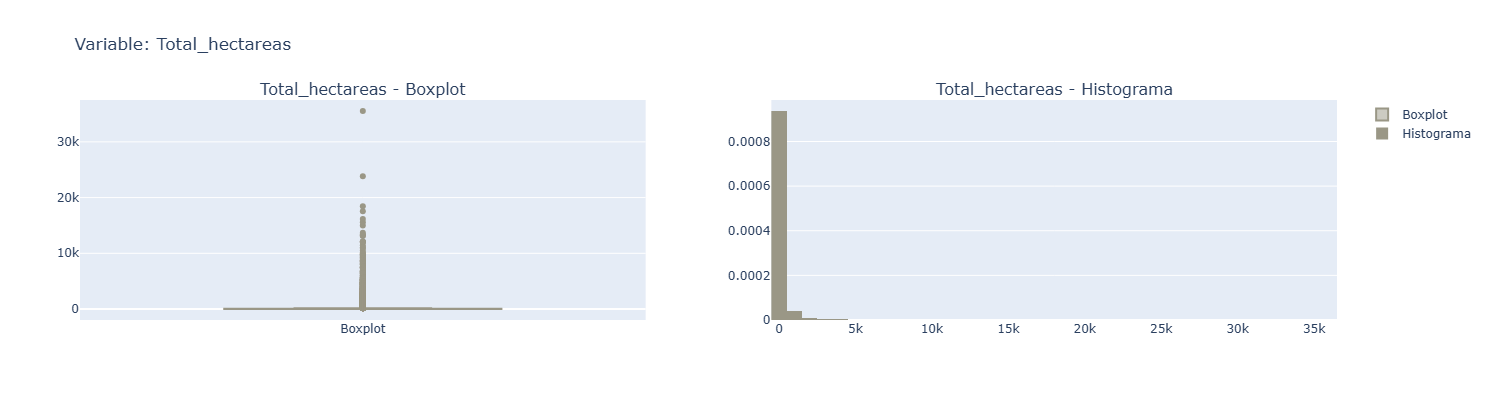

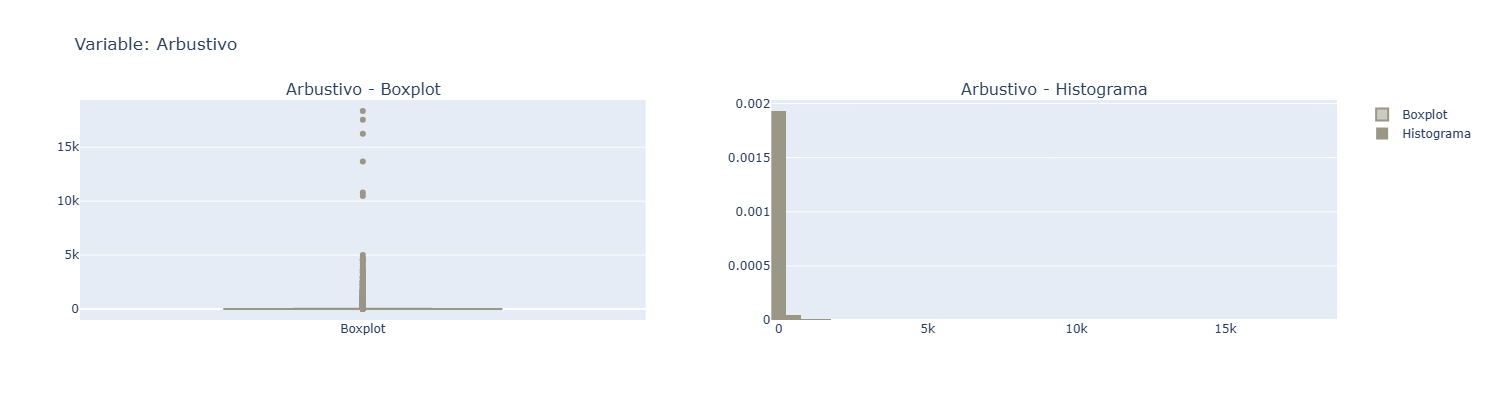

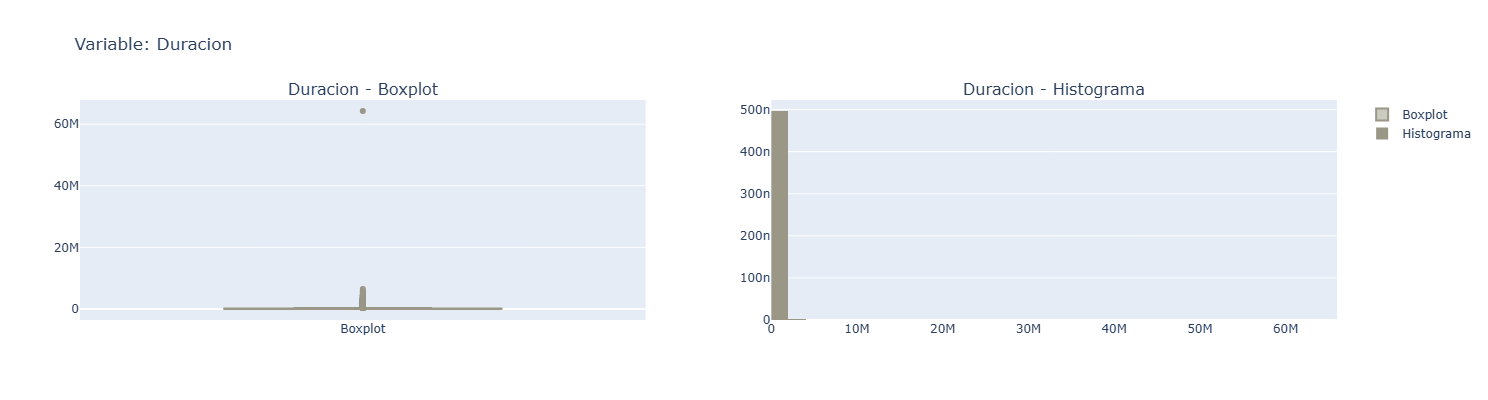

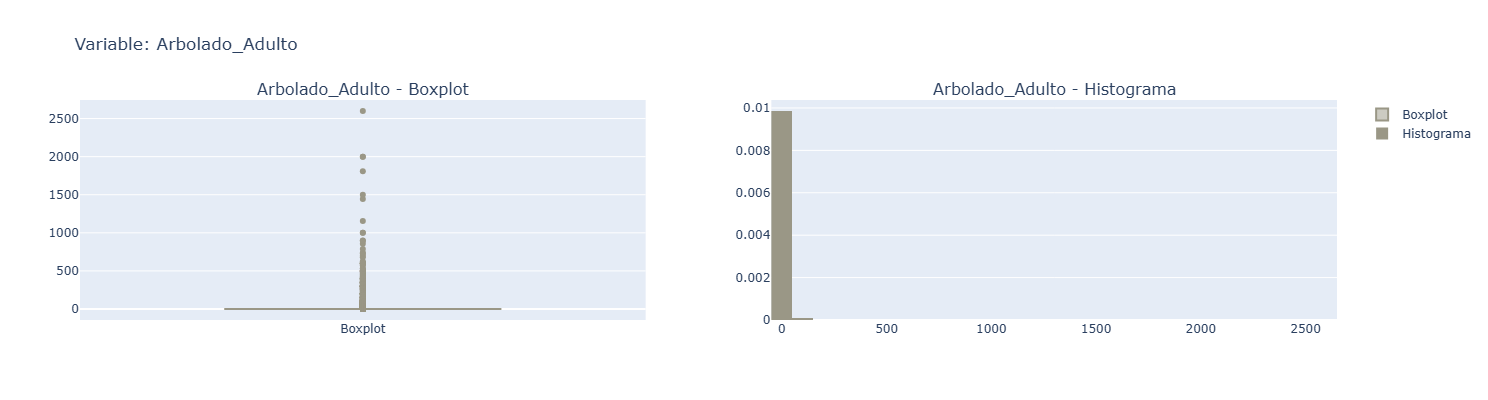

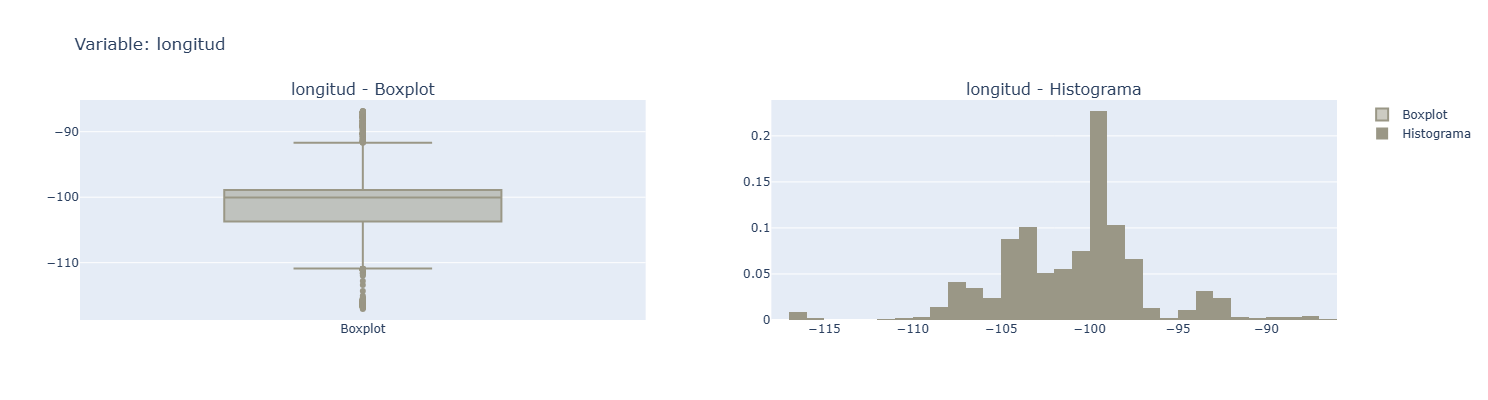

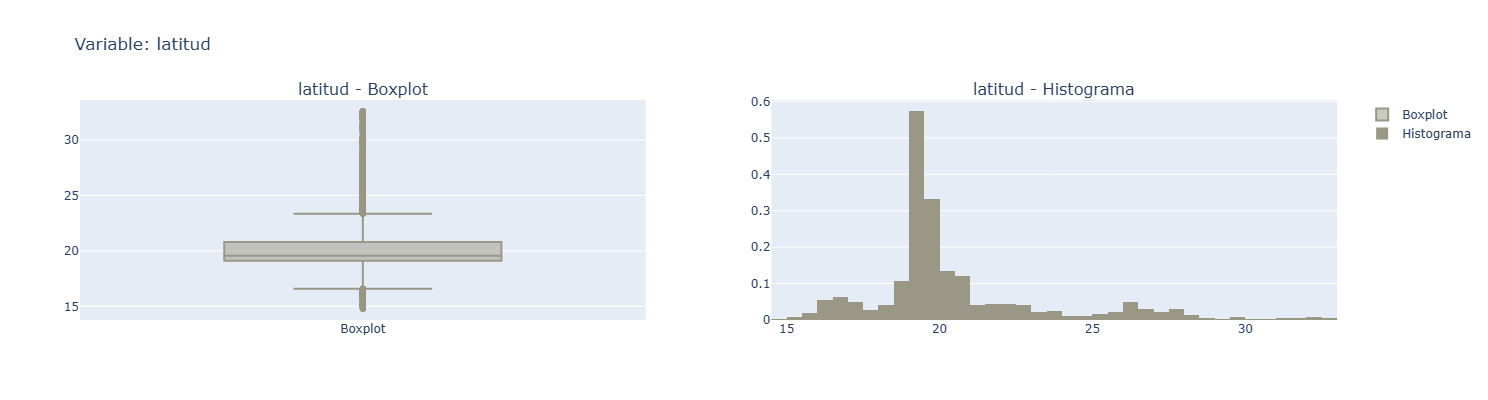

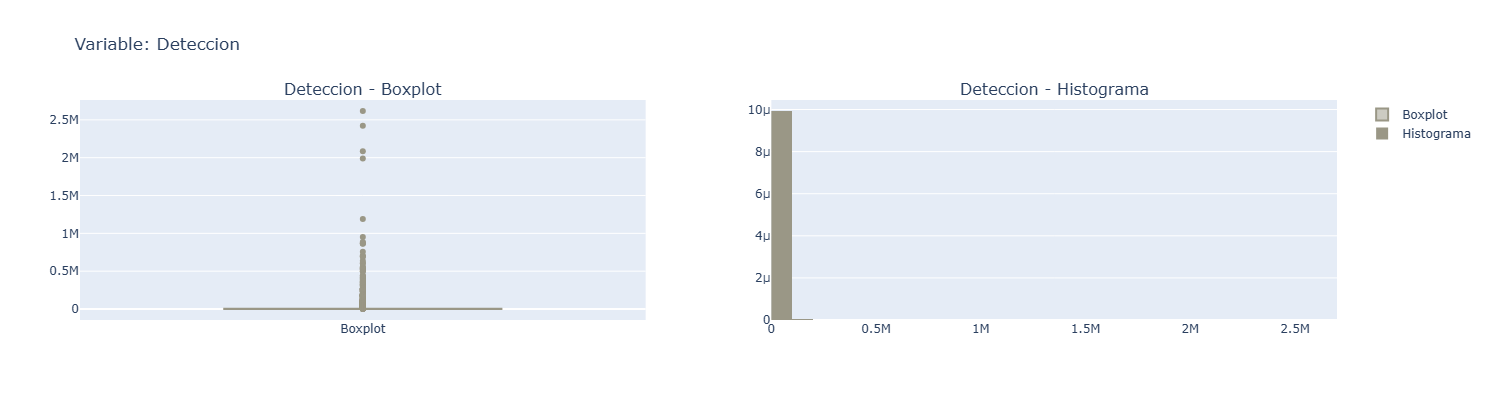

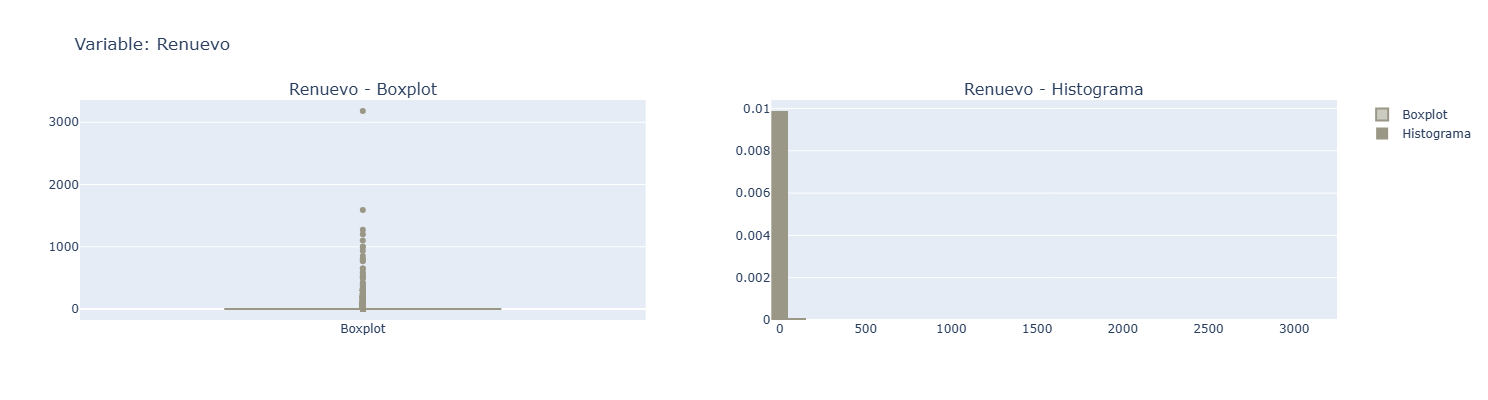

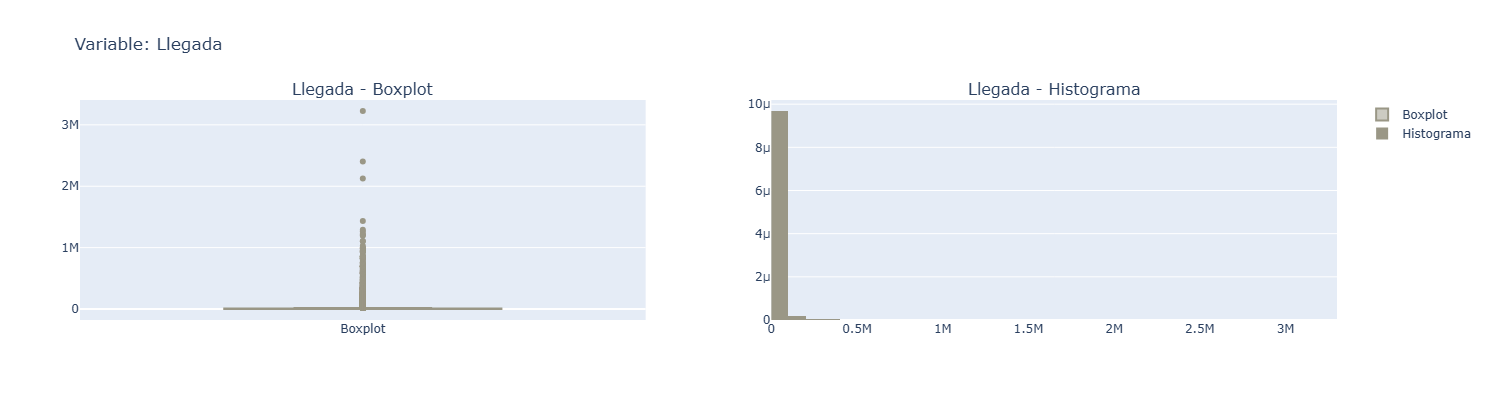

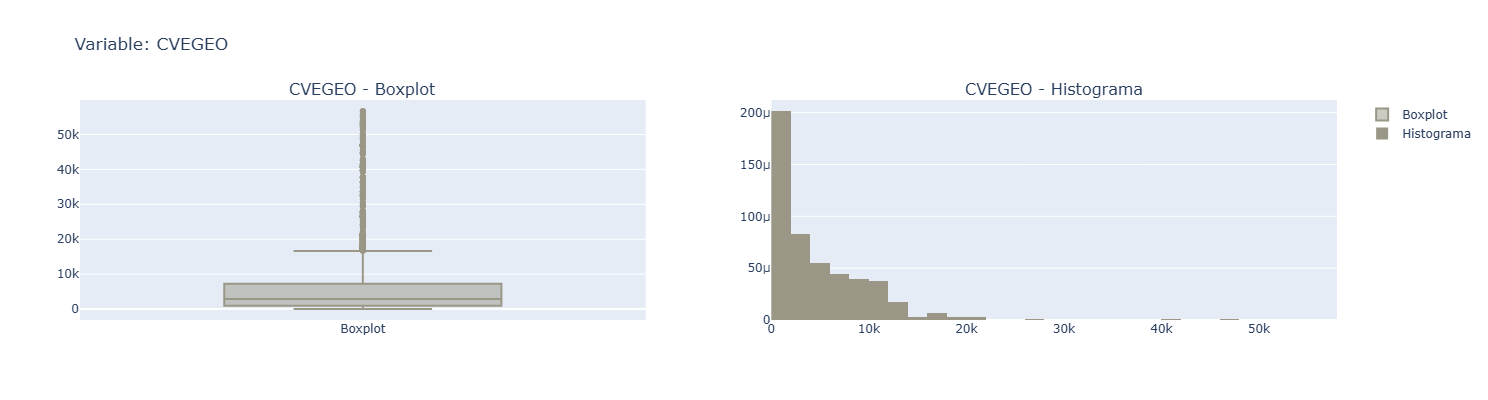

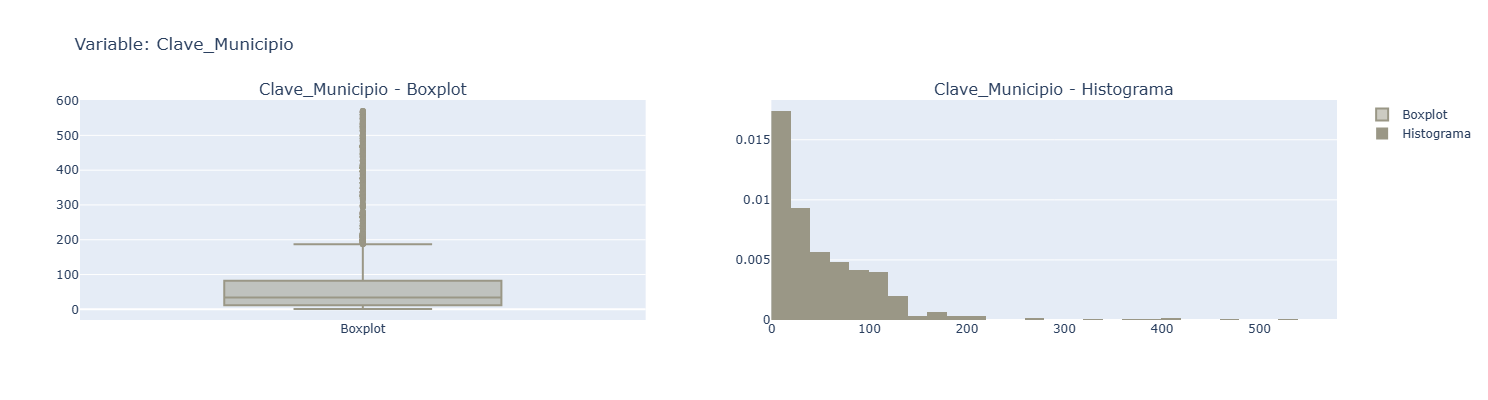

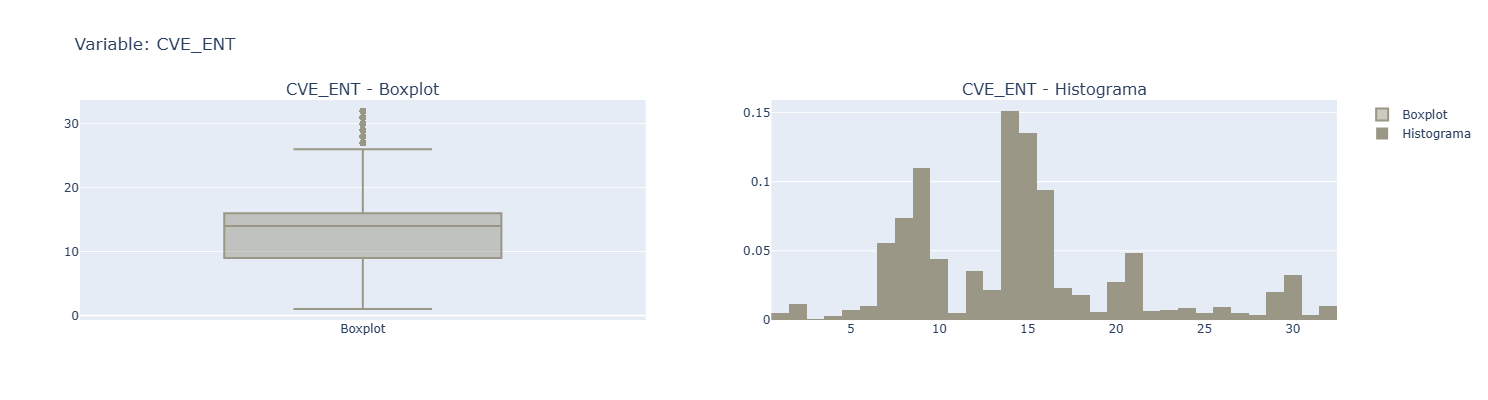

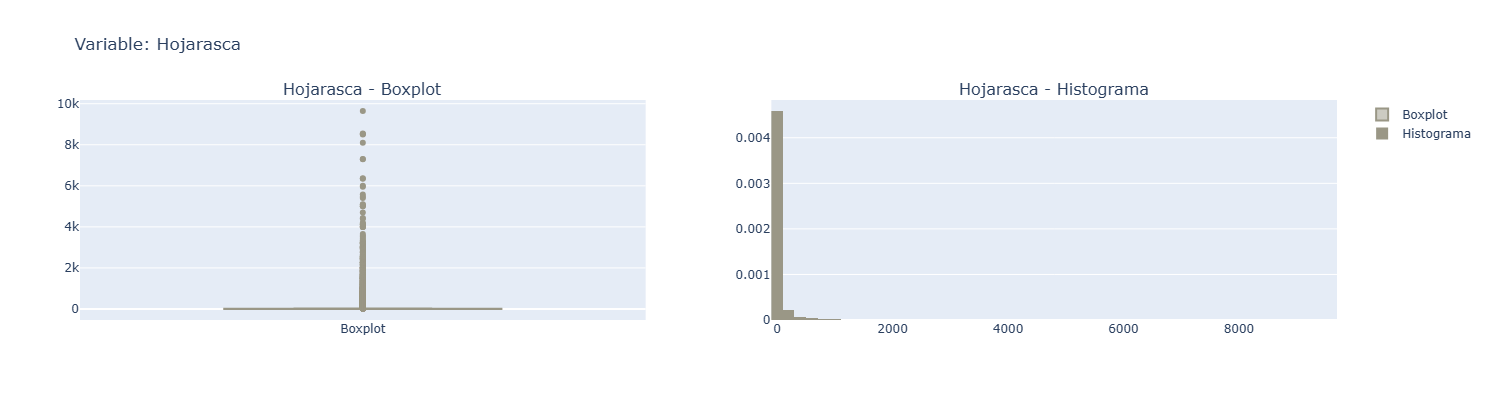

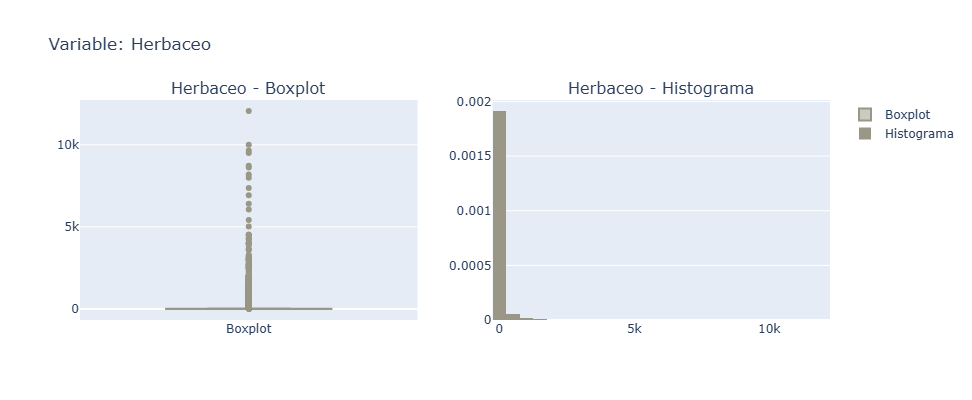

In [36]:
analisis.plot_num()

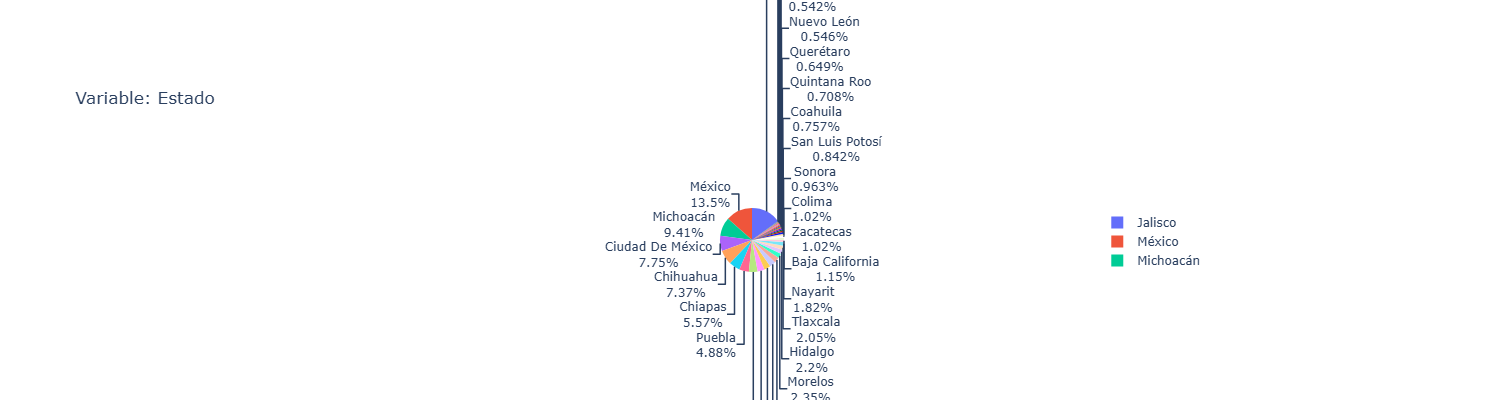

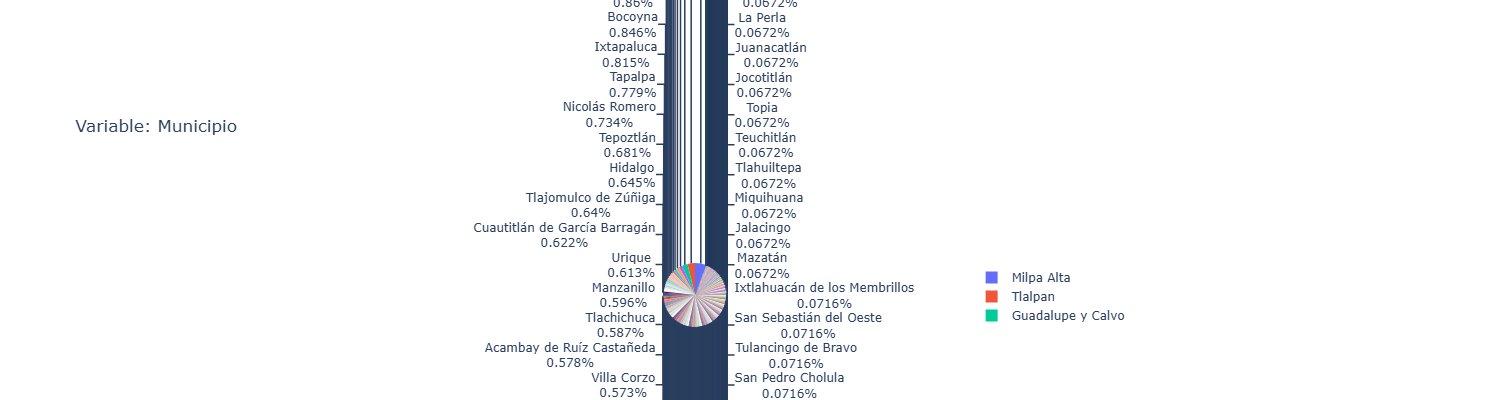

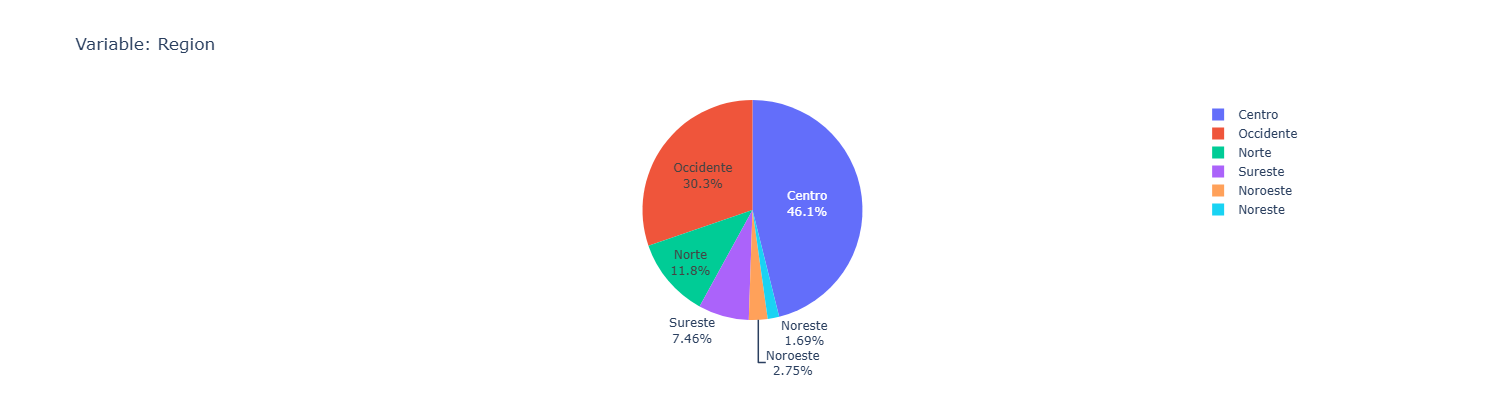

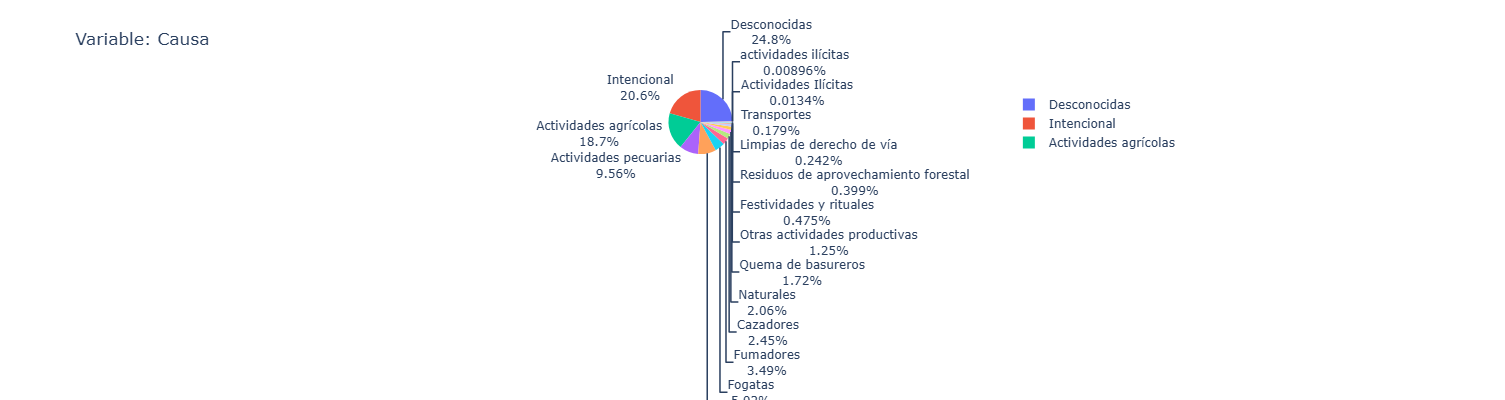

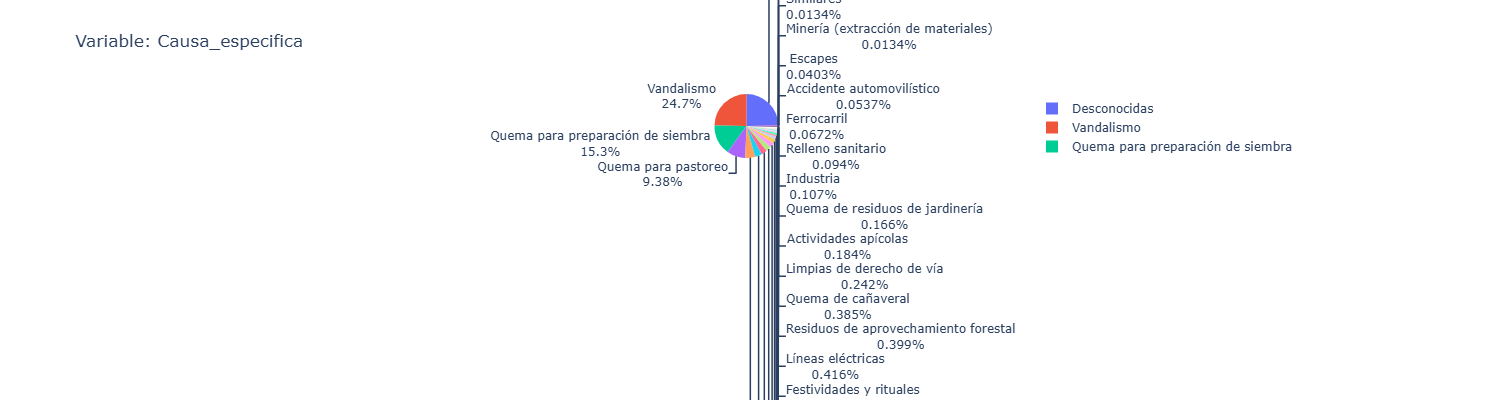

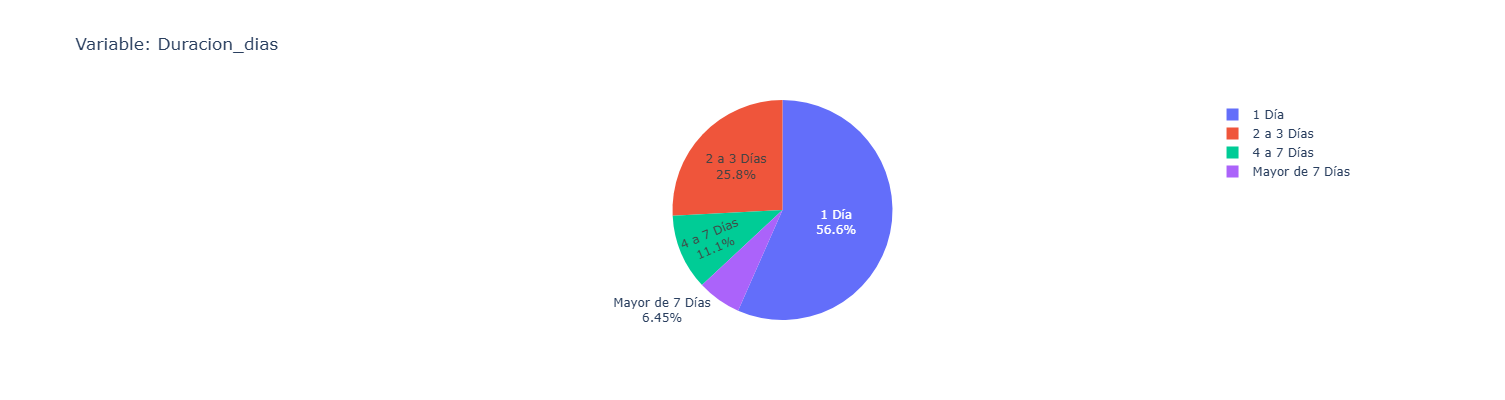

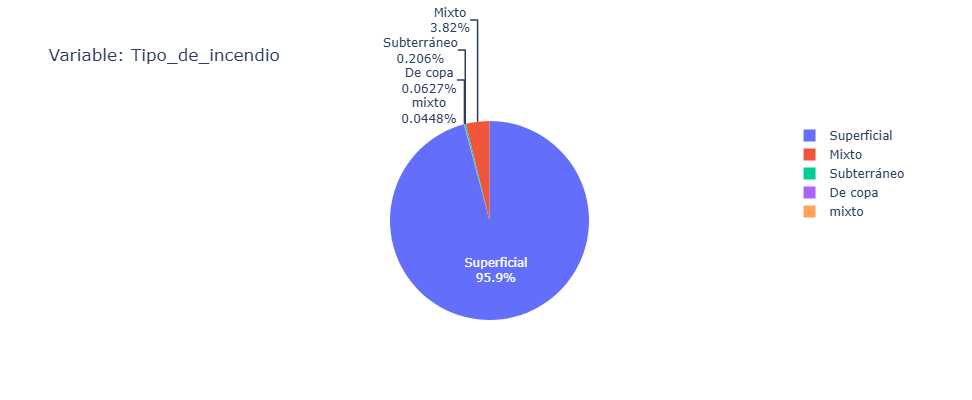

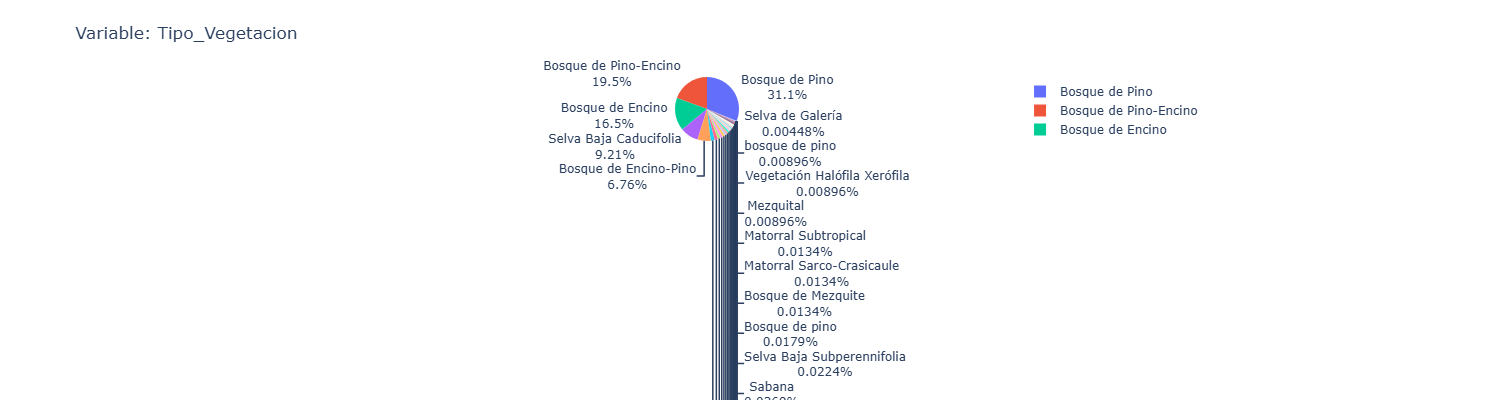

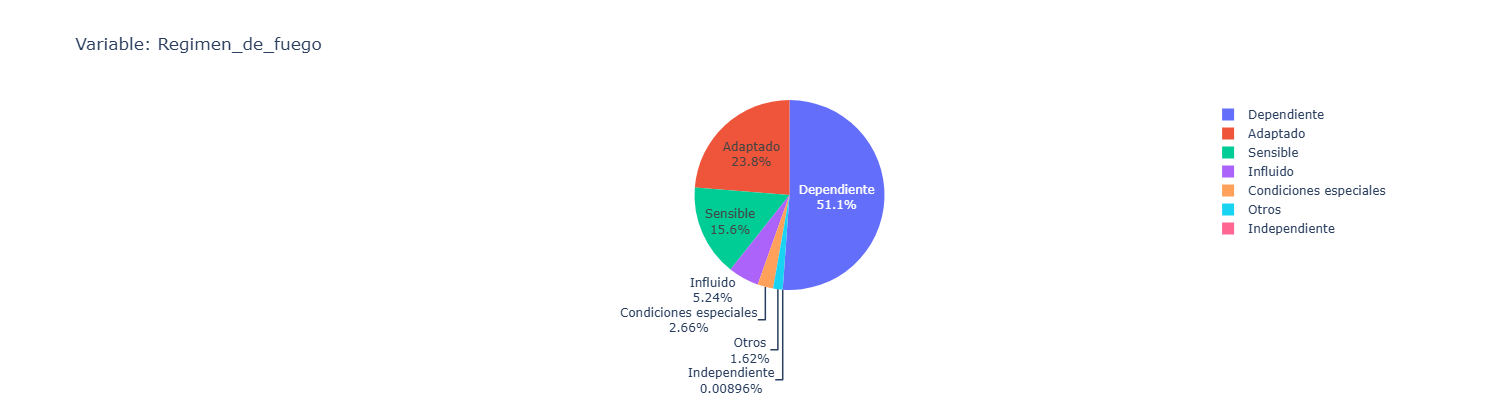

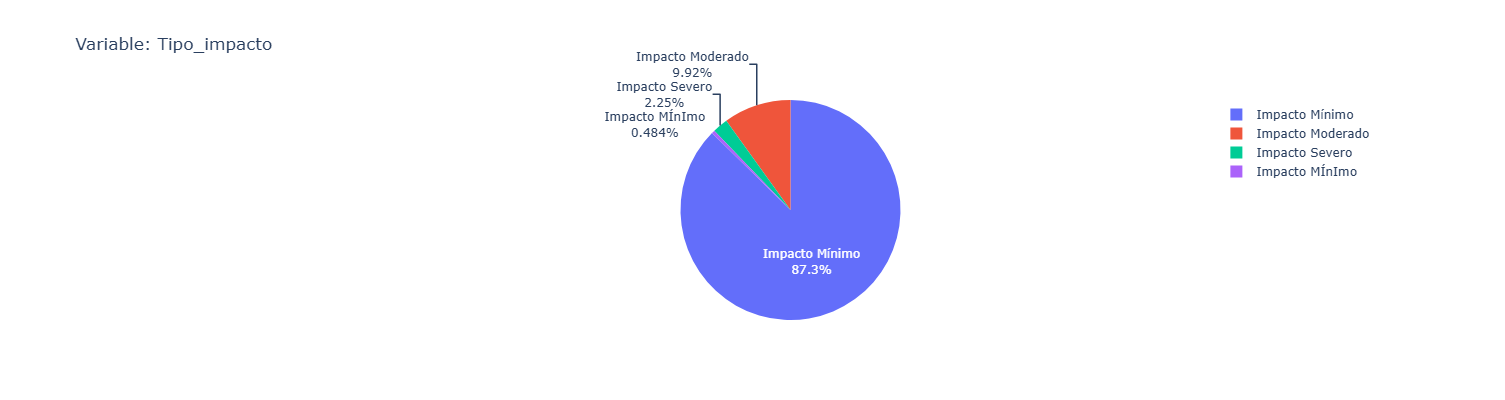

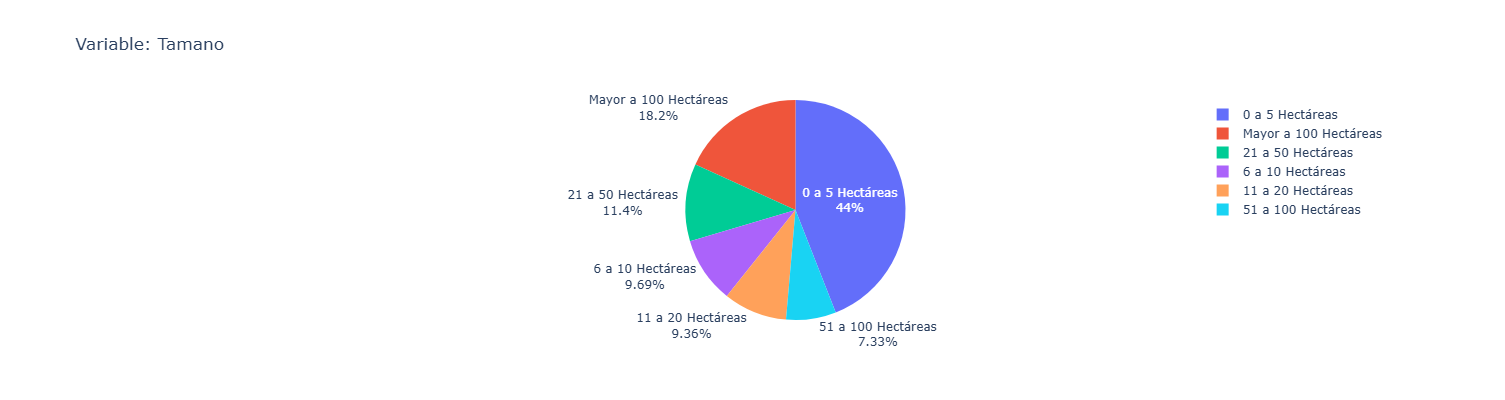

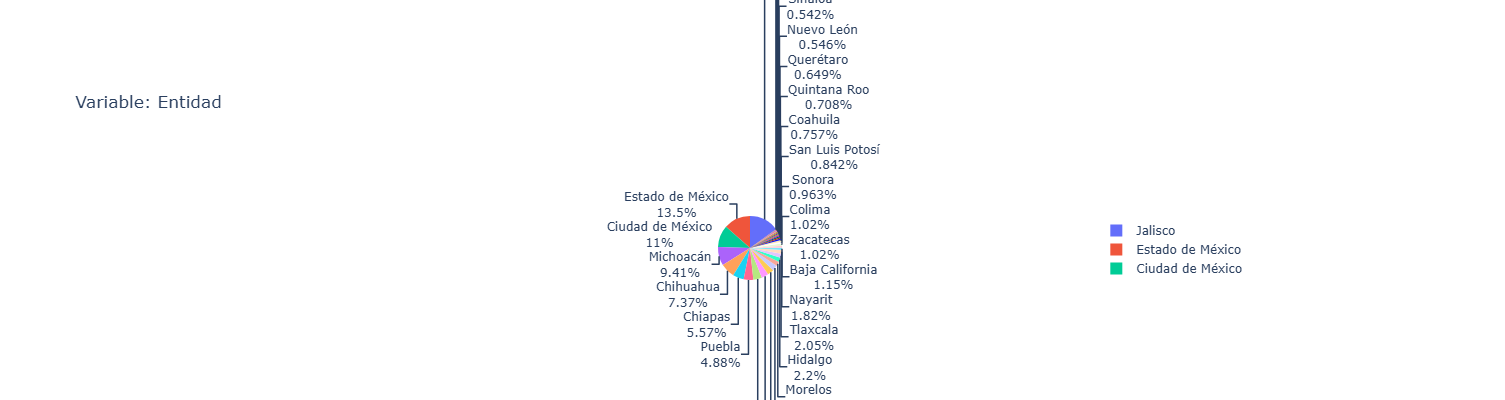

In [37]:
analisis.plot_cat()

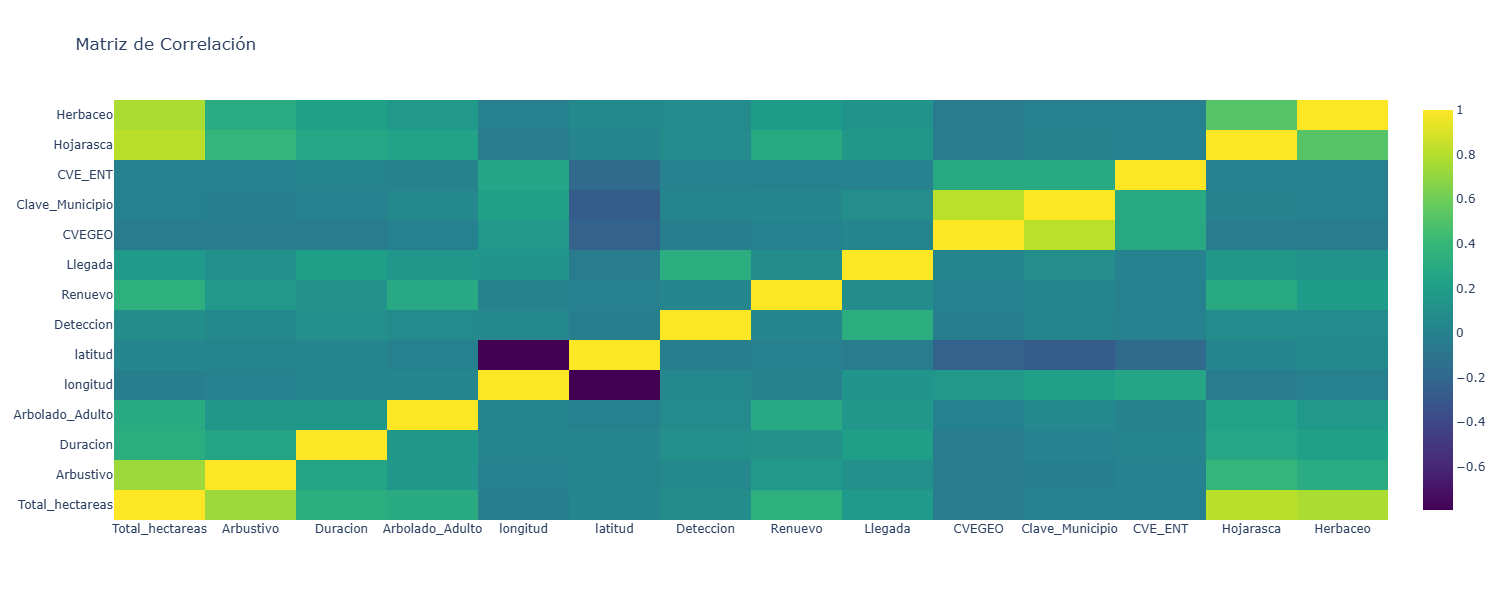

In [38]:
analisis.corr_matrix()

<h2 style="background-color:#E8E6D8; color:#595959;">Paso 4: Valores atípicos </h2> 

In [39]:
def outliers_iforest(df, contamination=0.04, random_state=1989):
    model = IForest(contamination=contamination, random_state=random_state)
    model.fit(df.values)
    preds = model.predict(df.values)
    return df[preds == 1]  # 1 = inliers, -1 = outliers

In [42]:
df_outliers = outliers_iforest(df[var_num])

In [43]:
df_outliers

,Total_hectareas,Arbustivo,Duracion,Arbolado_Adulto,longitud,latitud,Deteccion,Renuevo,Llegada,CVEGEO,Clave_Municipio,CVE_ENT,Hojarasca,Herbaceo
63,2512.5881,2502.8453,1356000,0.0000,-115.550289,31.523250,1560,0.0000,319200,102,1,2,0.00,9.7428
66,427.2344,414.3343,437400,12.9001,-115.912425,31.420494,900,0.0000,174900,102,1,2,0.00,0.0000
79,254.6153,203.6923,2226000,45.8307,-115.500842,31.110150,8100,5.0923,178200,102,1,2,0.00,0.0000
83,759.4439,493.7439,352800,38.0000,-116.226147,32.278208,1200,0.0000,7200,302,3,2,0.00,227.7000
114,8717.3282,0.0000,640800,0.0000,-92.062217,18.458861,36000,0.0000,37800,704,7,4,0.00,8717.3282
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22276,964.7500,964.7500,1730700,0.0000,-87.672789,21.423253,3600,0.0000,54000,9631,96,31,0.00,0.0000
22278,500.1400,500.1400,1209600,0.0000,-90.235911,20.752917,10020,0.0000,392400,1131,11,31,0.00,0.0000
22281,635.0200,635.0200,181200,0.0000,-87.695528,21.286000,70200,0.0000,86400,9631,96,31,0.00,0.0000
22307,2220.2300,10.0000,554400,0.0000,-103.476894,21.314169,300,0.0000,1200,1132,11,32,1800.23,410.0000


In [44]:
df_atipics = df.drop(df_outliers.index)

<h2 style="background-color:#E8E6D8; color:#595959;">Paso 5: Elección variables categóricas </h2> 

Se decide eliminar las siguientes variables debido a que las absorbe muy bien la variable **Region**:

1. Estado
2. Municipio
3. Entidad

In [45]:
df_atipics = df_atipics.drop(['Estado', 'Municipio', 'Entidad'], axis=1)

Se decide eliminar la variable **Causa_especifica** debido a que la variable **Causa** puede normalizarse para cubrir la funcionalidad de ambas.

In [46]:
df_atipics = df_atipics.drop(['Causa_especifica'], axis=1)

<h2 style="background-color:#E8E6D8; color:#595959;">Paso 6: Normalización variables categóricas </h2> 

Se decide normalizar la variable **Causa** y se reduce a las siguientes categorías:

1. intencional
2. accidental
3. natural
4. desconocida

In [47]:
df_atipics['Causa'] = df_atipics['Causa'].str.lower().str.strip()

In [48]:
df_atipics['Causa'].unique()

array(['actividades ilícitas', 'fumadores', 'actividades agrícolas',
       'desconocidas', 'fogatas', 'actividades pecuarias',
       'quema de basureros', 'transportes', 'naturales',
       'residuos de aprovechamiento forestal', 'cazadores',
       'otras actividades productivas', 'limpias de derecho de vía',
       'festividades y rituales', 'intencional'], dtype=object)

In [49]:
# Diccionario de mapeo por intencionalidad
mapping_intencionalidad = {
    # Intencionales
    'actividades ilícitas': 'intencional',
    'cazadores': 'intencional',
    'festividades y rituales': 'intencional',
    'fogatas': 'intencional',
    'fumadores': 'intencional',
    'quema de basureros': 'intencional',
    'intencional': 'intencional',

    # Accidentales / no intencionales
    'actividades agrícolas': 'accidental',
    'actividades pecuarias': 'accidental',
    'transportes': 'accidental',
    'residuos de aprovechamiento forestal': 'accidental',
    'otras actividades productivas' : 'accidental',
    'limpias de derecho de vía': 'accidental',

    # Naturales
    'naturales': 'natural',

    # Desconocidas
    'desconocidas': 'desconocida'
}

In [50]:
# Aplicar el mapeo
df_atipics['causa_intencion'] = df_atipics['Causa'].map(mapping_intencionalidad)

In [51]:
df_atipics = df_atipics.drop(['Causa'], axis=1)

In [52]:
df_atipics['causa_intencion'].unique()

array(['intencional', 'accidental', 'desconocida', 'natural'],
      dtype=object)

Se decide limpiar la variable **Tipo_de_incendio**:

In [45]:
df_atipics['Tipo_de_incendio'] = df_atipics['Tipo_de_incendio'].str.lower().str.strip()

In [46]:
df_atipics['Tipo_de_incendio'].unique()

array(['superficial', 'mixto', 'de copa', 'subterráneo'], dtype=object)

Se normaliza la variable **Tipo_Vegetacion**:

1. bosques
2. selvas
3. matorrales
4. pastizales y sabanas
5. humedales y vegetación especial
6. palmares
7. chaparrales y mezquitales

In [53]:
df_atipics['Tipo_Vegetacion'] = df_atipics['Tipo_Vegetacion'].str.lower().str.strip()

In [54]:
mapping_vegetacion = {
    # Bosques
    'bosque de mezquite': 'bosques',
    'bosque de encino': 'bosques',
    'bosque de pino': 'bosques',
    'bosque de galería': 'bosques',
    'vegetación de galería': 'bosques',
    'selva de galería': 'bosques',
    'bosque de táscate': 'bosques',
    'bosque de ayarín': 'bosques',
    'bosque de pino-encino': 'bosques',
    'bosque de encino-pino': 'bosques',
    'bosque de oyamel': 'bosques',
    'bosque inducido': 'bosques',
    'bosque cultivado': 'bosques',
    'bosque mesófilo de montaña': 'bosques',
    'bosque de cedro': 'bosques',

    # Selvas
    'selva baja caducifolia': 'selvas',
    'selva baja subcaducifolia': 'selvas',
    'selva baja perennifolia': 'selvas',
    'selva baja subperennifolia': 'selvas',
    'selva baja espinosa caducifolia': 'selvas',
    'selva baja espinosa subperennifolia': 'selvas',
    'selva mediana caducifolia': 'selvas',
    'selva mediana subcaducifolia': 'selvas',
    'selva mediana perennifolia': 'selvas',
    'selva mediana subperennifolia': 'selvas',
    'selva alta subperennifolia': 'selvas',
    'selva alta perennifolia': 'selvas',
    'manglar': 'selvas',

    # Matorrales
    'matorral crasicaule': 'matorrales',
    'matorral sarcocaule': 'matorrales',
    'matorral sarco-crasicaule': 'matorrales',
    'matorral desértico micrófilo': 'matorrales',
    'matorral desértico rosetófilo': 'matorrales',
    'matorral espinoso tamaulipeco': 'matorrales',
    'matorral submontano': 'matorrales',
    'matorral subtropical': 'matorrales',
    'matorral rosetófilo costero': 'matorrales',

    # Pastizales y sabanas
    'pastizal natural': 'pastizales',
    'pastizal halófilo': 'pastizales',
    'pradera de alta montaña': 'pastizales',
    'sabana': 'pastizales',
    'sabanoide': 'pastizales',

    # Humedales y vegetación especial
    'tular': 'humedales',
    'popal': 'humedales',
    'vegetación halófila xerófila': 'humedales',
    'vegetación halófila hidrófila': 'humedales',
    'vegetación de dunas costeras': 'humedales',

    # Palmares
    'palmar natural': 'palmares',
    'palmar inducido': 'palmares',

    # Chaparrales y mezquitales
    'chaparral': 'chaparrales/mezquitales',
    'mezquital': 'chaparrales/mezquitales',
    'mezquital xerófilo': 'chaparrales/mezquitales',
}

In [55]:
# Aplicar el mapeo
df_atipics['grupo_vegetacion'] = df_atipics['Tipo_Vegetacion'].map(mapping_vegetacion)

In [56]:
df_atipics = df_atipics.drop(['Tipo_Vegetacion'], axis=1)

In [57]:
df_atipics['grupo_vegetacion'].unique()

array(['matorrales', 'bosques', 'selvas', 'pastizales',
       'chaparrales/mezquitales', 'palmares', 'humedales'], dtype=object)

Se normaliza la variable **Tipo_impacto**:

1. impacto mínimo
2. impacto moderado
3. impacto severo

In [60]:
df_atipics['Tipo_impacto'] = df_atipics['Tipo_impacto'].str.lower().str.strip()

In [61]:
df_atipics['Tipo_impacto'].unique()

array(['impacto mínimo', 'impacto moderado', 'impacto severo'],
      dtype=object)

In [62]:
df_atipics.to_csv("../data/incendios_clean.csv", index=False)

<h2 style="background-color:#E8E6D8; color:#595959;">Paso 7: Codificación variables categóricas </h2> 

In [63]:
# Region: LabelEncoder
le_region = LabelEncoder()
df_atipics["region_encode"] = le_region.fit_transform(df_atipics["Region"])

# causa_intencion: LabelEncoder
le_intent = LabelEncoder()
df_atipics["causa_encode"] = le_intent.fit_transform(df_atipics["causa_intencion"])

# Tipo_de_incendio: LabelEncoder
le_tipoin = LabelEncoder()
df_atipics["Tipo_de_incendio_encode"] = le_tipoin.fit_transform(df_atipics["Tipo_de_incendio"])

# grupo_vegetacion: LabelEncoder
le_veget = LabelEncoder()
df_atipics["vegetacion_encode"] = le_veget.fit_transform(df_atipics["grupo_vegetacion"])

# Regimen_de_fuego: LabelEncoder
le_regfueg = LabelEncoder()
df_atipics["regimen_fuego_encode"] = le_regfueg.fit_transform(df_atipics["Regimen_de_fuego"])

In [64]:
# Duracion_dias: OrdinalEncoder
df_atipics["Duracion_dias"] = df_atipics["Duracion_dias"].str.lower().str.strip()

orden_duraci = [["1 día", "2 a 3 días", "4 a 7 días", "mayor de 7 días"]]
oe = OrdinalEncoder(categories=orden_duraci)
df_atipics["duracion_encode"] = oe.fit_transform(df_atipics[["Duracion_dias"]]).astype(int)

# Tipo_impacto: OrdinalEncoder
df_atipics["Tipo_impacto"] = df_atipics["Tipo_impacto"].str.lower().str.strip()

orden_impacto = [["impacto mínimo", "impacto moderado", "impacto severo"]]
oe = OrdinalEncoder(categories=orden_impacto)
df_atipics["impacto_encode"] = oe.fit_transform(df_atipics[["Tipo_impacto"]]).astype(int)

# Tamano: OrdinalEncoder
df_atipics["Tamano"] = df_atipics["Tamano"].str.lower().str.strip()

orden_tamano = [["0 a 5 hectáreas", "6 a 10 hectáreas", "11 a 20 hectáreas", "21 a 50 hectáreas", 
                 "51 a 100 hectáreas", "mayor a 100 hectáreas"]]
oe = OrdinalEncoder(categories=orden_tamano)
df_atipics["tamano_encode"] = oe.fit_transform(df_atipics[["Tamano"]]).astype(int)

In [65]:
#Eliminamos las variables ya codificadas
df_atipics = df_atipics.drop(["Region", "causa_intencion", "Tipo_de_incendio", "grupo_vegetacion", "Regimen_de_fuego",
                             "Duracion_dias", "Tipo_impacto", "Tamano"], axis = 1)

<h2 style="background-color:#E8E6D8; color:#595959;">Paso 8: Escalado </h2>

Usamos RobustScaler porque en el EDA pudimos observar que teniamos varios valores atípicos, por lo que los valores extremos no influirán en el escalado

In [72]:
#Usamos robust-scaling
robustscaler = RobustScaler()
robustscaler.fit(df_atipics[var_num])

,with_centering,True
,with_scaling,True
,quantile_range,"(25.0, ...)"
,copy,True
,unit_variance,False


In [73]:
df_std = pd.DataFrame(robustscaler.transform(df_atipics[var_num]), columns = df_atipics[var_num].columns, index =  df_atipics[var_num].index)

In [74]:
df_std.head()

,Total_hectareas,Arbustivo,Duracion,Arbolado_Adulto,longitud,latitud,Deteccion,Renuevo,Llegada,CVEGEO,Clave_Municipio,CVE_ENT,Hojarasca,Herbaceo
0,1.321365,1.036414,0.000000,0.0,-0.468252,1.471530,1.4,0.0,0.166667,-0.282211,-0.333333,-1.857143,0.0,4.865294
1,0.470793,0.039974,-0.052402,0.0,-0.475839,1.287769,2.6,0.0,0.333333,-0.438388,-0.478261,-1.857143,0.0,2.284255
2,0.875668,0.144602,-0.026201,0.0,-0.477756,1.282694,2.6,0.0,0.333333,-0.438388,-0.478261,-1.857143,0.0,3.793501
3,0.050500,-0.068638,-0.046579,0.0,-0.471898,1.374620,0.0,0.0,-0.388889,-0.438388,-0.478261,-1.857143,0.0,0.717531
4,1.225653,0.598623,-0.052402,0.0,-0.521436,1.322681,1.0,0.0,0.444444,-0.438388,-0.478261,-1.857143,0.0,4.822104


<h2 style="background-color:#E8E6D8; color:#595959;">Paso 9: TAD </h2> 

<p> Concatenación de variables numéricas y categóricas </p>

In [84]:
data = pd.concat([df_std, df_cat], axis = 1)

In [85]:
data

,Total_hectareas,Arbustivo,Duracion,Arbolado_Adulto,longitud,latitud,Deteccion,Renuevo,Llegada,CVEGEO,...,Hojarasca,Herbaceo,region_encode,causa_encode,Tipo_de_incendio_encode,vegetacion_encode,regimen_fuego_encode,duracion_encode,impacto_encode,tamano_encode
0,1.321365,1.036414,0.000000,0.0,-0.468252,1.471530,1.40,0.0,0.166667,-0.282211,...,0.000000,4.865294,4,2,3,3,5,0,0,4
1,0.470793,0.039974,-0.052402,0.0,-0.475839,1.287769,2.60,0.0,0.333333,-0.438388,...,0.000000,2.284255,4,2,3,3,5,0,0,3
2,0.875668,0.144602,-0.026201,0.0,-0.477756,1.282694,2.60,0.0,0.333333,-0.438388,...,0.000000,3.793501,4,2,3,3,5,0,0,3
3,0.050500,-0.068638,-0.046579,0.0,-0.471898,1.374620,0.00,0.0,-0.388889,-0.438388,...,0.000000,0.717531,4,2,3,3,5,0,0,1
4,1.225653,0.598623,-0.052402,0.0,-0.521436,1.322681,1.00,0.0,0.444444,-0.438388,...,0.000000,4.822104,4,2,3,3,5,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22327,0.335752,-0.128535,0.087336,0.0,-0.660659,1.532377,2.00,0.0,-0.666667,0.409808,...,0.000000,1.882303,4,2,3,5,2,0,0,2
22328,-0.155668,-0.128535,8.943231,0.0,-0.892667,1.938433,0.20,0.0,-0.666667,0.316102,...,0.155641,-0.146485,4,2,3,0,2,3,0,0
22329,0.064675,0.142674,0.524017,0.0,-0.747561,0.971306,0.40,0.0,-0.666667,-0.277370,...,0.000000,0.612725,4,1,3,6,6,1,2,1
22330,-0.118115,-0.128535,-0.160116,0.0,-0.542785,1.947783,0.08,0.0,-0.388889,0.425426,...,0.000000,0.101381,4,1,3,3,6,0,2,0


In [86]:
data.to_csv(f"../data/tad_incendios.csv")

<h2 style="background-color:#E8E6D8; color:#595959;">Paso 10: Reducción de dimensiones </h2> 

<h2 style="color:#9A9786; font-size: 1.2em; font-weight: bold;"> PCA </h2>

In [89]:
pca_= PCA(n_components=3)

In [90]:
pca_.fit(data)

,n_components,3
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [91]:
data_pca=pd.DataFrame(pca_.transform(data),columns=["PC1","PC2","PC3"])

In [92]:
data_pca

,PC1,PC2,PC3
0,-0.976955,-2.943265,1.118913
1,0.072667,-4.149469,-0.759868
2,0.136775,-3.679111,-0.119218
3,-2.640351,-4.543671,-1.491281
4,-1.379599,-3.046053,0.735201
...,...,...,...
21433,-0.613211,-4.360387,-1.106837
21434,-2.394201,-4.166239,-1.477304
21435,-2.222593,-4.499821,-1.235980
21436,-2.600663,-4.808696,-1.805725


In [93]:
#Porcentaje de varianza explicada por cada uno de los componentes seleccionados.
pca_.explained_variance_ratio_

array([0.41488784, 0.2741305 , 0.10511434])

In [94]:
sum(pca_.explained_variance_ratio_)

0.794132684285953

In [96]:
for n_compo in range(1,22):
    print(f"N componentes : {n_compo}")
    pca = PCA(n_components=n_compo)
    pca.fit(data)
    print(sum(pca.explained_variance_ratio_))
    print("\n")

N componentes : 1
0.4148878404879352


N componentes : 2
0.6890183426513969


N componentes : 3
0.794132684285953


N componentes : 4
0.8638052288250101


N componentes : 5
0.8989432275698411


N componentes : 6
0.933339646050783


N componentes : 7
0.9586205586241778


N componentes : 8
0.9793949757853277


N componentes : 9
0.9859566787819161


N componentes : 10
0.990603511084276


N componentes : 11
0.9934991651806351


N componentes : 12
0.9954404600516639


N componentes : 13
0.9967075241921848


N componentes : 14
0.9978378906310371


N componentes : 15
0.9985811251965424


N componentes : 16
0.9991913944195039


N componentes : 17
0.9995009056093358


N componentes : 18
0.9996821919484329


N componentes : 19
0.9998179892059351


N componentes : 20
0.9999171000693422


N componentes : 21
0.9999999999995194




In [97]:
# Varianza explicada acumulada
explained_variance = np.cumsum(pca.explained_variance_ratio_)

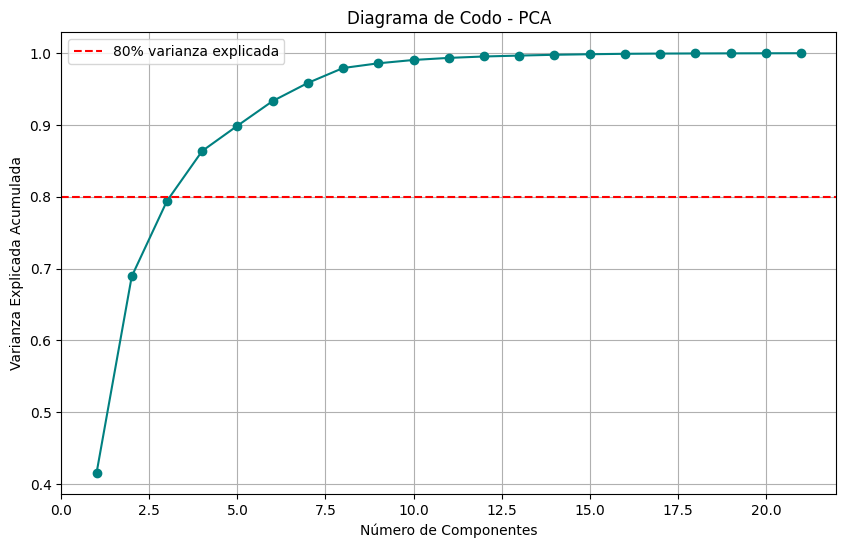

In [100]:
# Graficar
plt.figure(figsize=(10,6))
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o', color='teal')
plt.axhline(y=0.80, color='red', linestyle='--', label='80% varianza explicada')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada Acumulada')
plt.title('Diagrama de Codo - PCA')
plt.grid(True)
plt.legend()
plt.show()

<h2 style="background-color:#E8E6D8; color:#595959;">Paso 11: Clusterización </h2> 

<img src="../imgs/metricas_clustering_proyecto.png" alt="En verde podemos ver que a Kmenas le fue bien en todas las métricas" width="600" style="display: block; margin: 0 auto;">

<h2 style="color:#9A9786; font-size: 1.2em; font-weight: bold;">  KMeans | GMM | DBSCAN - 3 Componentes </h2>

In [106]:
%%time
results = []

for n in [3]:
    # --- KMeans ---
    kmeans = KMeans(n_clusters=5, random_state=42)
    labels_kmeans = kmeans.fit_predict(data_pca)
    results.append({
        "n_components": n,
        "method": "KMeans",
        "Silhouette": silhouette_score(data_pca, labels_kmeans),
        "Davies-Bouldin": davies_bouldin_score(data_pca, labels_kmeans),
        "Calinski-Harabasz": calinski_harabasz_score(data_pca, labels_kmeans)
    })
    
    # --- DBSCAN ---
    dbscan = DBSCAN(eps=0.5, min_samples=10)
    labels_dbscan = dbscan.fit_predict(data_pca)
    if len(set(labels_dbscan)) > 1:  # evitar error si todo queda en un cluster
        results.append({
            "n_components": n,
            "method": "DBSCAN",
            "Silhouette": silhouette_score(data_pca, labels_dbscan),
            "Davies-Bouldin": davies_bouldin_score(data_pca, labels_dbscan),
            "Calinski-Harabasz": calinski_harabasz_score(data_pca, labels_dbscan)
        })
    
    # --- GMM ---
    gmm = GaussianMixture(n_components=5, random_state=42)
    labels_gmm = gmm.fit_predict(data_pca)
    results.append({
        "n_components": n,
        "method": "GMM",
        "Silhouette": silhouette_score(data_pca, labels_gmm),
        "Davies-Bouldin": davies_bouldin_score(data_pca, labels_gmm),
        "Calinski-Harabasz": calinski_harabasz_score(data_pca, labels_gmm)
    })

# Resultados a DataFrame
results_df = pd.DataFrame(results)
print(results_df)

   n_components  method  Silhouette  Davies-Bouldin  Calinski-Harabasz
0             3  KMeans    0.814388        0.749119       14786.601500
1             3  DBSCAN    0.365481        1.541556         246.266114
2             3     GMM    0.179216        1.313729        6393.442249
CPU times: total: 45.9 s
Wall time: 1min 36s


<h2 style="color:#9A9786; font-size: 1.2em; font-weight: bold;">  Silueta KMEANS 10 clusters </h2>

N Clusters : 2
Score Silueta : 0.99


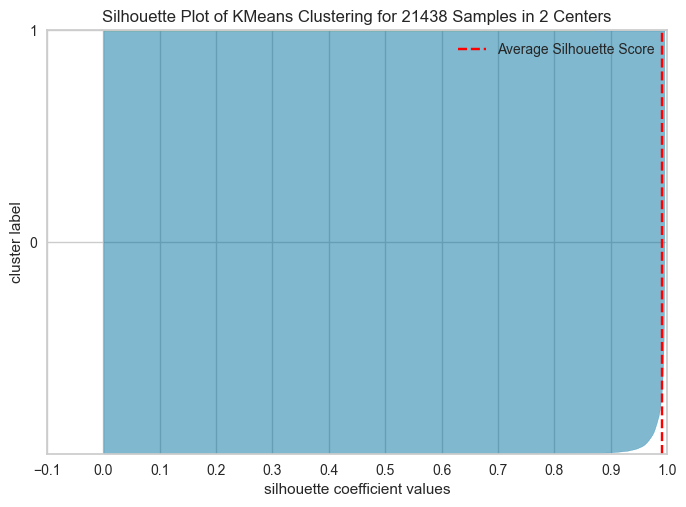

N Clusters : 3
Score Silueta : 0.88


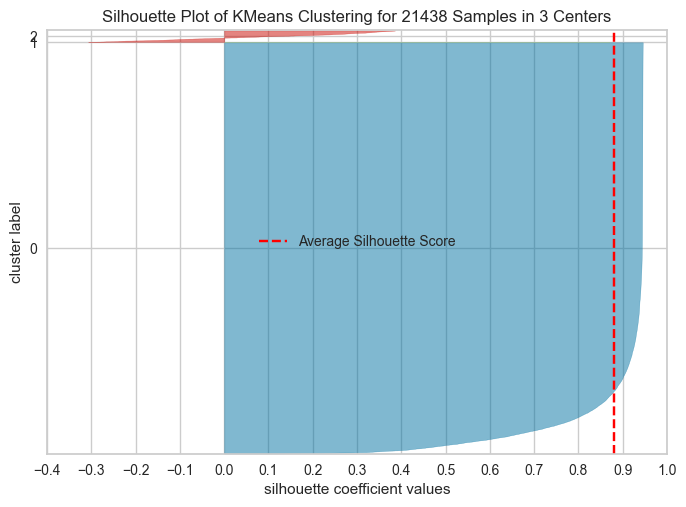

N Clusters : 4
Score Silueta : 0.86


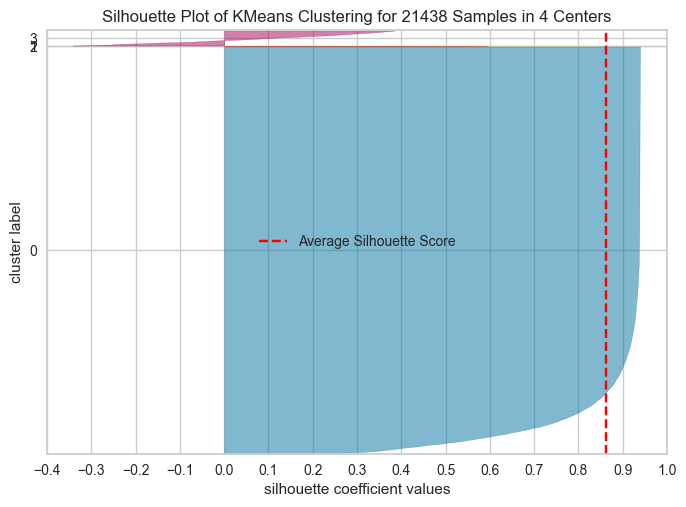

N Clusters : 5
Score Silueta : 0.84


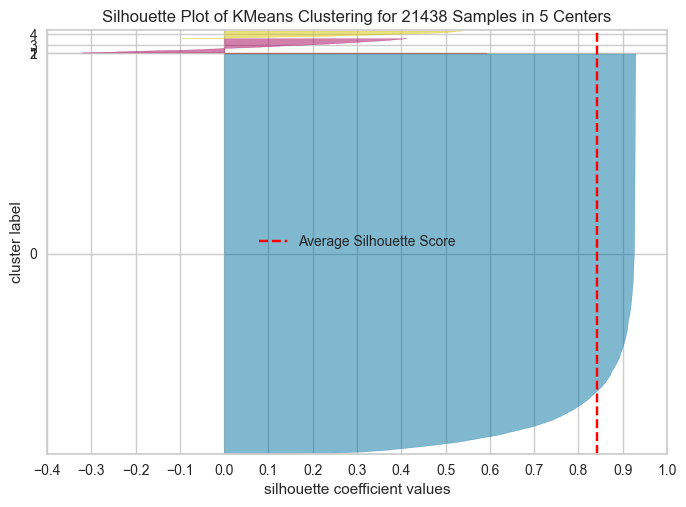

N Clusters : 6
Score Silueta : 0.83


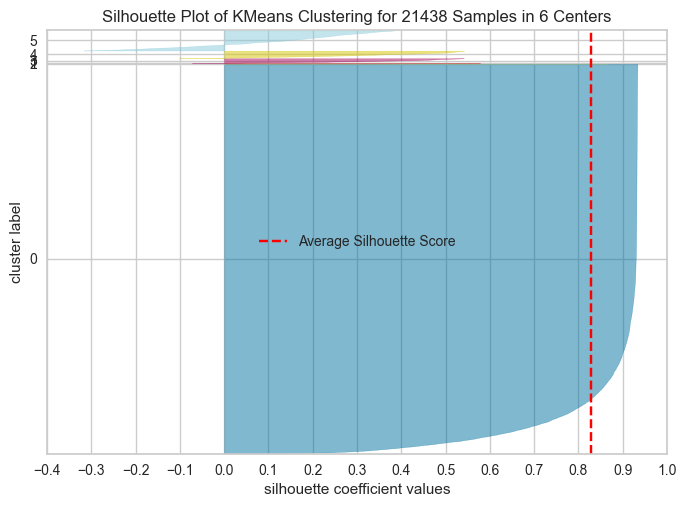

N Clusters : 7
Score Silueta : 0.8


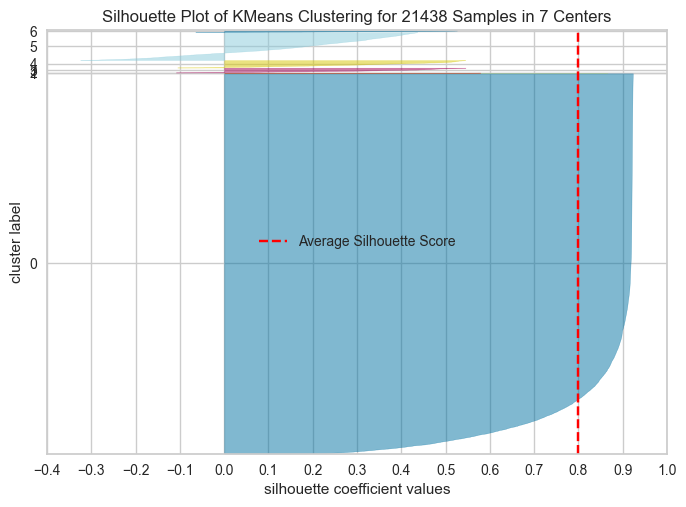

N Clusters : 8
Score Silueta : 0.78


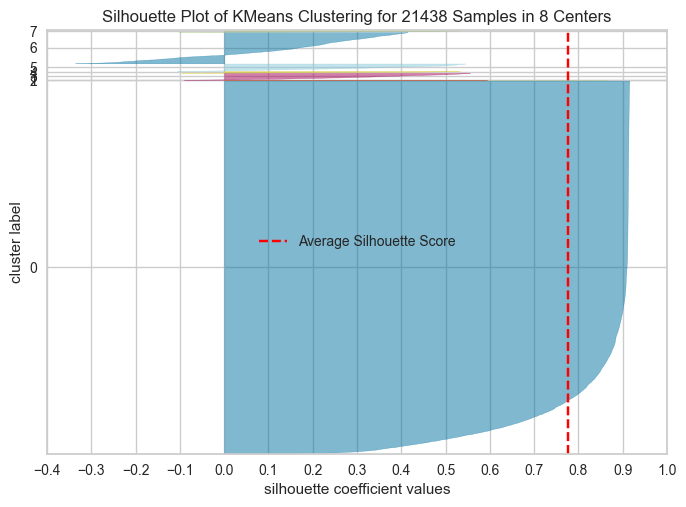

N Clusters : 9
Score Silueta : 0.76


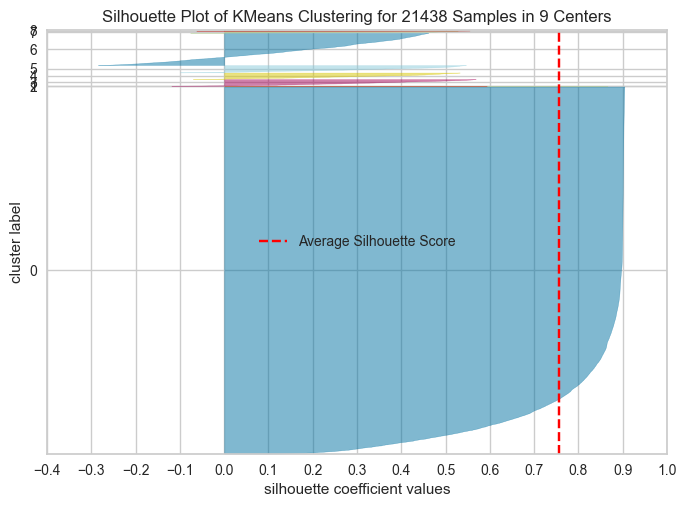

CPU times: total: 6min 29s
Wall time: 3min 21s


In [107]:
%%time
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=200)
    visualizer = SilhouetteVisualizer(km, colors='yellowbrick')
    visualizer.fit(data_pca)
    print(f"N Clusters : {k}")
    print(f"Score Silueta : {round(visualizer.silhouette_score_, 2)}")
    visualizer.show()

<h2 style="color:#9A9786; font-size: 1.2em; font-weight: bold;"> Codo KMeans - 20 Componentes </h2>

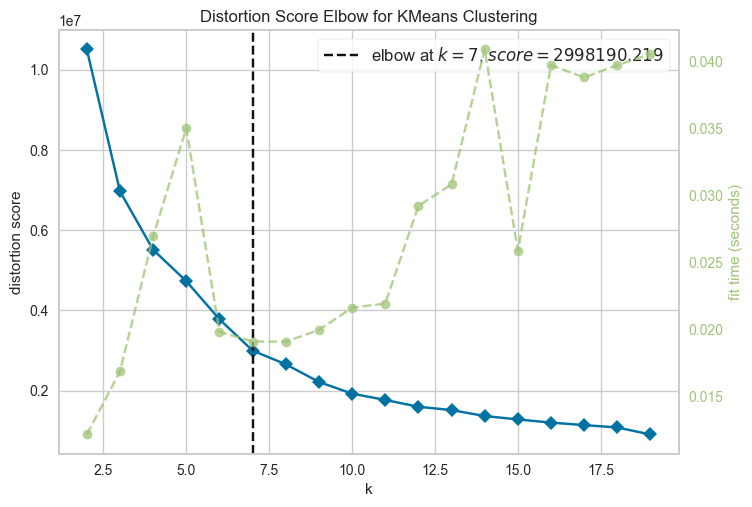

CPU times: total: 4.14 s
Wall time: 1.27 s


<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [109]:
%%time
# Función para graficar el codo
def codo(X, min_compo, max_compo):
    model = KMeans(random_state=42)
    visualizer = KElbowVisualizer(model, k=(min_compo, max_compo))
    visualizer.fit(X)
    return visualizer.show()

# Ejecución del codo
codo(data_pca, 2, 20)

<h2 style="color:#9A9786; font-size: 1.2em; font-weight: bold;"> KMeans - Distribución de clusters </h2>

In [121]:
%%time
# KMeans con 3 clusters
KM_4 = KMeans(n_clusters=3, n_init=100, init='k-means++', random_state=42).fit(data_pca)

data_pca['cluster_4'] = KM_4.labels_

# Contar elementos por cluster
pie = data_pca.groupby('cluster_4').size().reset_index()
pie.columns = ['cluster_4', 'value']

CPU times: total: 5.27 s
Wall time: 1.09 s


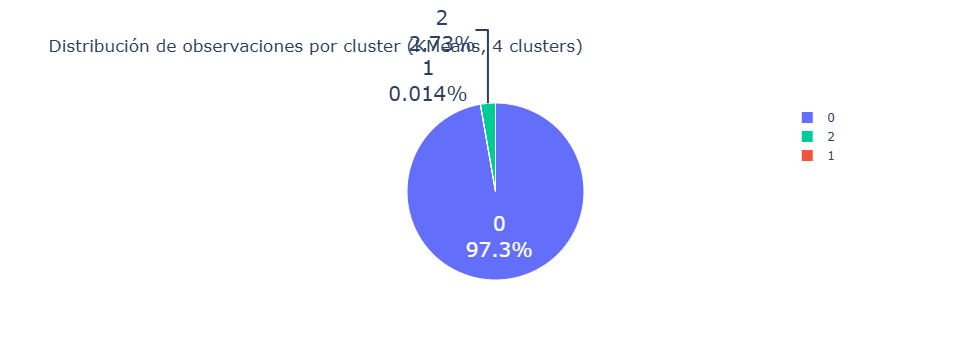

In [122]:
# Gráfico de pastel
fig = px.pie(
    pie,
    values='value',
    names='cluster_4',
    color='cluster_4',
    title="Distribución de observaciones por cluster (KMeans, 4 clusters)"
)

fig.update_traces(
    hoverinfo='label+percent',
    textinfo='percent+label',
    textfont_size=20,
    marker=dict(line=dict(color='white', width=1))
)

fig.update_layout(uniformtext_minsize=15, uniformtext_mode='hide')
fig.show()

<h2 style="color:#9A9786; font-size: 1.2em; font-weight: bold;"> KMeans - Visualización de clusters a 3 componentes  </h2>

In [117]:
%%time
# KMeans con 4 clusters
KM_4 = KMeans(n_clusters=3, n_init=100, init='k-means++', random_state=42).fit(data_pca)
labels = KM_4.labels_

# Crear DataFrame con etiquetas
datos_vis = pd.DataFrame({
    "comp1": data_pca.iloc[:,0],
    "comp2": data_pca.iloc[:,1],
    "comp3": data_pca.iloc[:,2],
    "cluster": labels
})

CPU times: total: 5.36 s
Wall time: 1 s


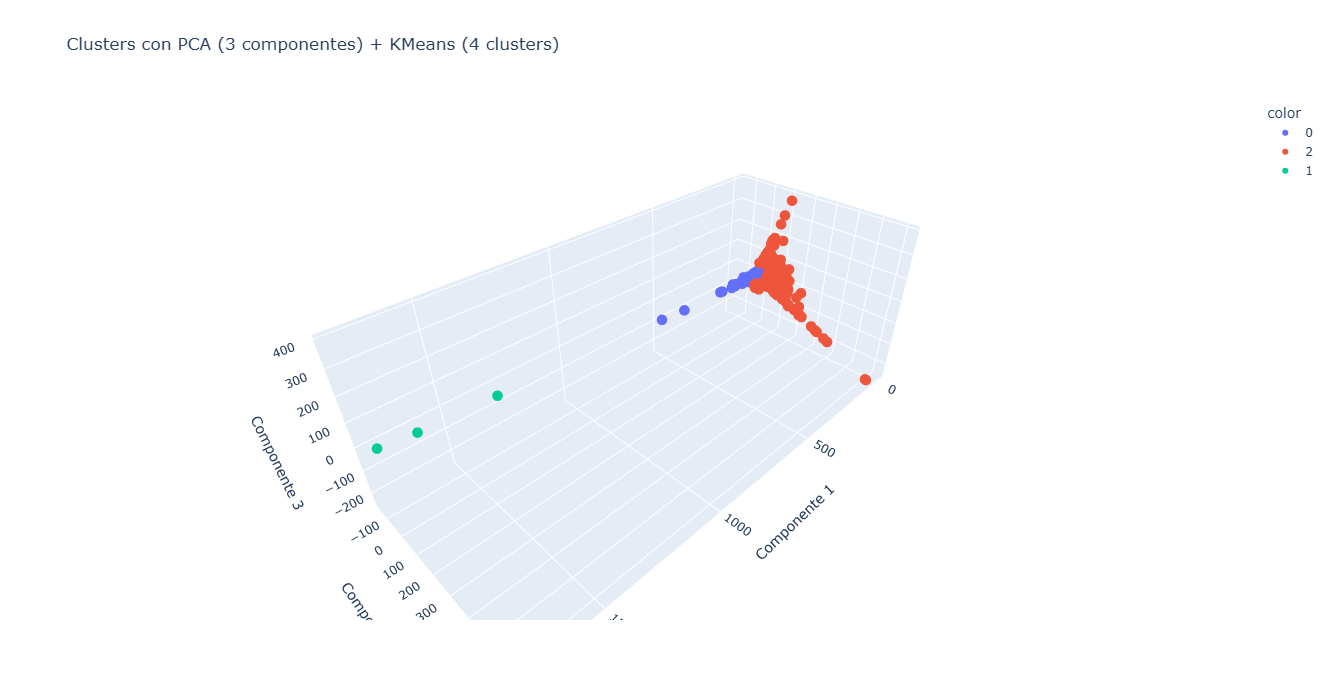

In [118]:
# Gráfico 3D
fig = px.scatter_3d(
    datos_vis, x="comp1", y="comp2", z="comp3",
    color=datos_vis["cluster"].astype(str),
    labels={"comp1": "Componente 1", "comp2": "Componente 2", "comp3": "Componente 3"},
    title="Clusters con PCA (3 componentes) + KMeans (4 clusters)"
)

# Personalización de puntos
fig.update_traces(
    marker=dict(size=6, line=dict(width=0, color="Black")),
    selector=dict(mode="markers")
)

# Tamaño gráfico
fig.update_layout(
    width=900,   # ancho
    height=700   # alto
)


fig.show()

<h2 style="background-color:#E8E6D8; color:#595959;">Paso 12: perfilamiento </h2> 

<h2 style="color:#9A9786; font-size: 1.2em; font-weight: bold;"> Archivo origen </h2>

In [123]:
df_perf=pd.read_csv("../data/incendios_clean.csv")

In [126]:
df_perf = df_perf.drop(["Clave_del_incendio"], axis = 1)

In [127]:
df_perf.head()

,latitud,longitud,Clave_Municipio,CVE_ENT,CVEGEO,Region,Duracion_dias,Tipo_de_incendio,Regimen_de_fuego,Tipo_impacto,...,Arbustivo,Herbaceo,Hojarasca,Total_hectareas,Tamano,Deteccion,Llegada,Duracion,causa_intencion,grupo_vegetacion
0,21.997253,-102.230097,11,1,1101,Occidente,1 Día,Superficial,Otros,impacto mínimo,...,9.06330,51.35820,0.0,60.4215,51 a 100 Hectáreas,2700,4500,25200,intencional,matorrales
1,21.694700,-102.265758,1,1,101,Occidente,1 Día,Superficial,Otros,impacto mínimo,...,1.31100,24.90900,0.0,26.2200,21 a 50 Hectáreas,4500,5400,19800,intencional,matorrales
2,21.686344,-102.274769,1,1,101,Occidente,1 Día,Superficial,Otros,impacto mínimo,...,2.12500,40.37500,0.0,42.5000,21 a 50 Hectáreas,4500,5400,22500,intencional,matorrales
3,21.837694,-102.247233,1,1,101,Occidente,1 Día,Superficial,Otros,impacto mínimo,...,0.46600,8.85400,0.0,9.3200,6 a 10 Hectáreas,600,1500,20400,intencional,matorrales
4,21.752181,-102.480086,1,1,101,Occidente,1 Día,Superficial,Otros,impacto mínimo,...,5.65729,50.91561,0.0,56.5729,51 a 100 Hectáreas,2100,6000,19800,intencional,matorrales


<h2 style="color:#9A9786; font-size: 1.2em; font-weight: bold;"> Kmeans 3 componentes </h2>

In [136]:
KM_3 = KMeans(n_clusters=3, n_init=100, init='k-means++', random_state=42)
df_perf["cluster_3"] = KM_3.fit_predict(data_pca)

<h2 style="color:#9A9786; font-size: 1.2em; font-weight: bold;"> Categóricas  </h2>

In [137]:
def plot_categorical_by_cluster(
    df: pd.DataFrame,
    cat_col: str,
    cluster_col: str,
    top_k: int = 10,
    normalize: str = "cluster"
):
    d = df[[cluster_col, cat_col]].copy()
    top_cats = d[cat_col].astype("object").value_counts(dropna=False).head(top_k).index
    d = d[d[cat_col].astype("object").isin(top_cats)]
    ct = pd.crosstab(d[cluster_col], d[cat_col])

    if normalize == "cluster":
        pct = (ct.div(ct.sum(axis=1), axis=0) * 100)
        ylabel = "% dentro del clúster"
    else:
        pct = (ct / ct.values.sum() * 100)
        ylabel = "% global"

    plt.figure(figsize=(10, 5))
    pct.T.plot(kind="bar")
    plt.title(f"Distribución de {cat_col} por clúster ({cluster_col})")
    plt.xlabel(cat_col)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

In [140]:
v_feats = ["Region", "Duracion_dias", "Tipo_de_incendio", "Tipo_impacto", "Tamano", "causa_intencion", "grupo_vegetacion"]

<Figure size 1000x500 with 0 Axes>

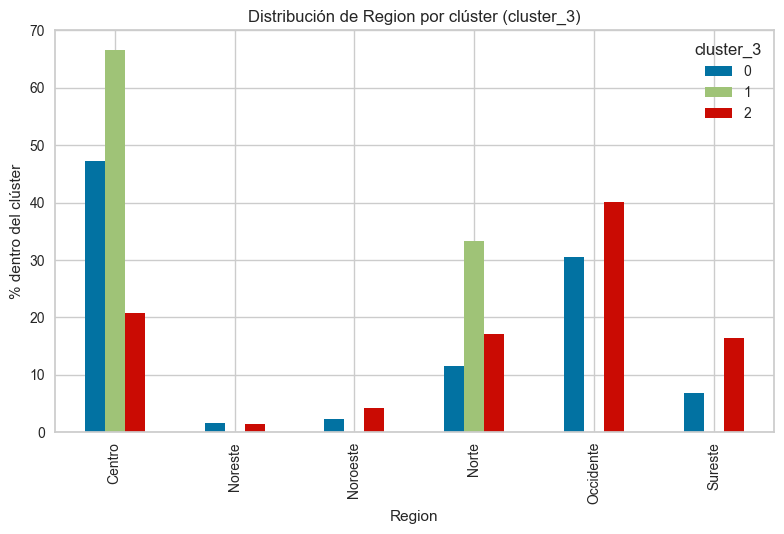

<Figure size 1000x500 with 0 Axes>

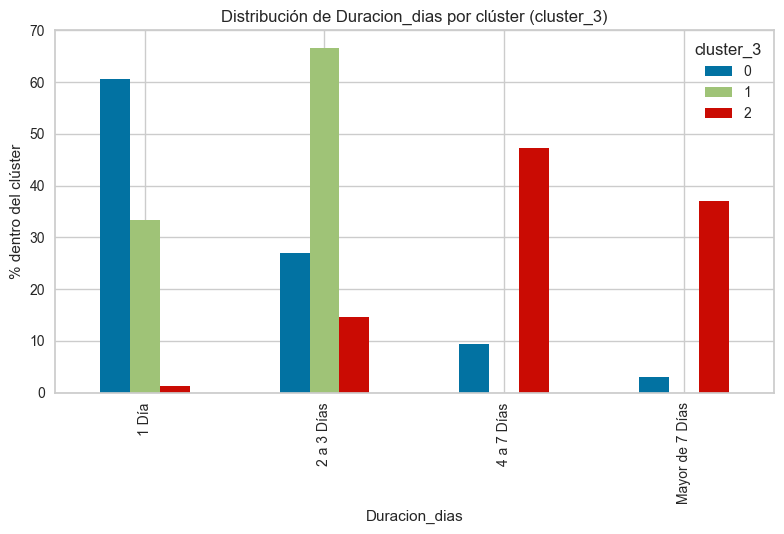

<Figure size 1000x500 with 0 Axes>

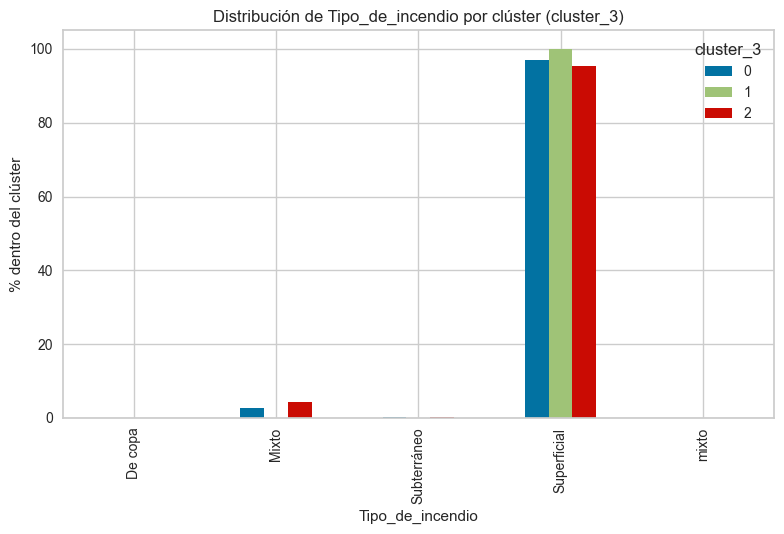

<Figure size 1000x500 with 0 Axes>

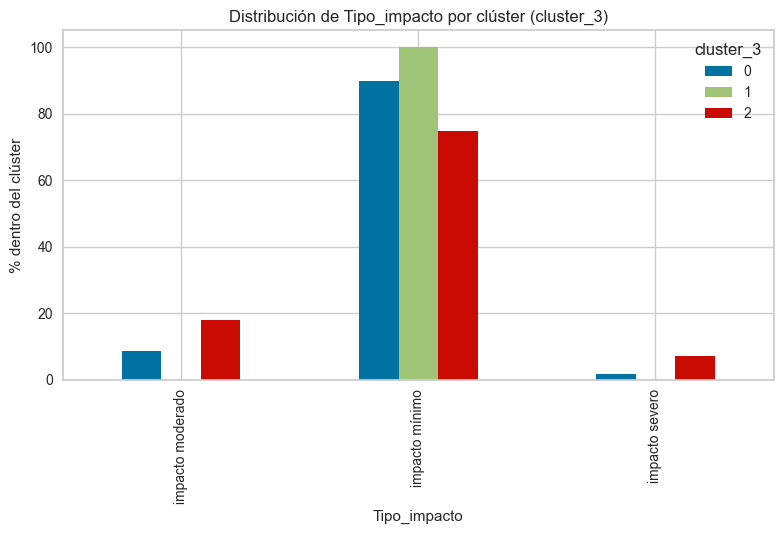

<Figure size 1000x500 with 0 Axes>

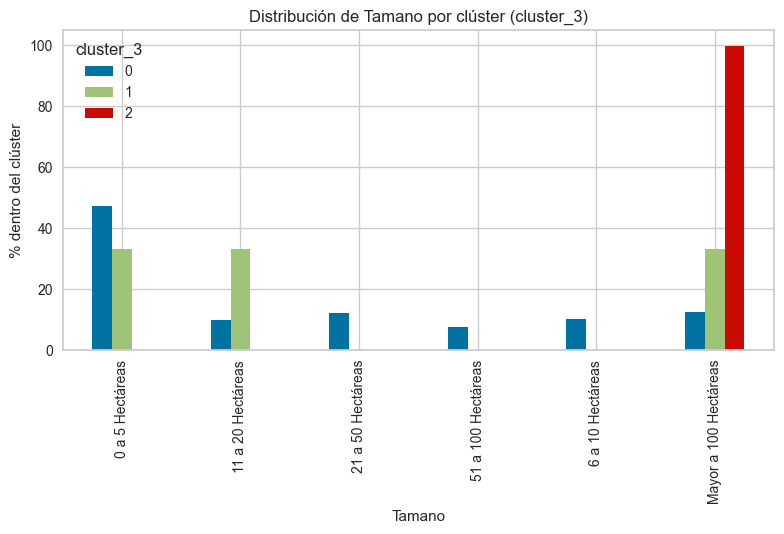

<Figure size 1000x500 with 0 Axes>

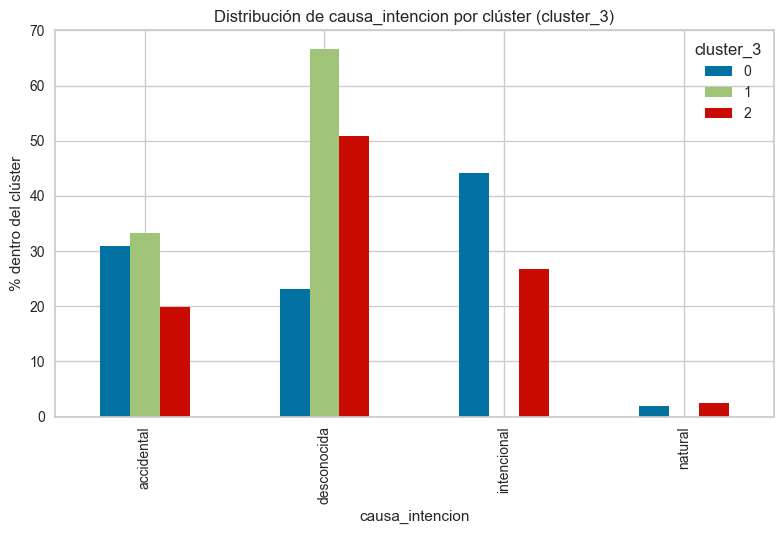

<Figure size 1000x500 with 0 Axes>

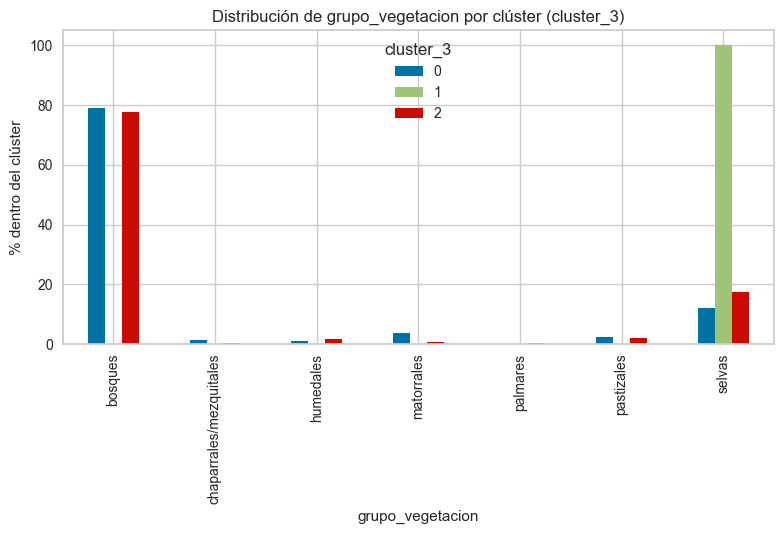

CPU times: total: 1.86 s
Wall time: 1.86 s


In [141]:
%%time
for col in v_feats:
    plot_categorical_by_cluster(df=df_perf, cat_col=col, cluster_col="cluster_3")

<h2 style="color:#9A9786; font-size: 1.2em; font-weight: bold;"> Numéricas  </h2>

In [161]:
df_perf['cluster_3n'] = KM_3.labels_

In [162]:
df_perf.columns

Index(['latitud', 'longitud', 'Clave_Municipio', 'CVE_ENT', 'CVEGEO', 'Region',
       'Duracion_dias', 'Tipo_de_incendio', 'Regimen_de_fuego', 'Tipo_impacto',
       'Arbolado_Adulto', 'Renuevo', 'Arbustivo', 'Herbaceo', 'Hojarasca',
       'Total_hectareas', 'Tamano', 'Deteccion', 'Llegada', 'Duracion',
       'causa_intencion', 'grupo_vegetacion', 'cluster_3', 'cluster_3n'],
      dtype='object')

In [169]:
perfil_num = df_perf.groupby("cluster_3n")[["Arbolado_Adulto", "Renuevo", "Arbustivo", "Hojarasca", 
                                            "Total_hectareas", "Llegada", "Duracion", "Deteccion"]].mean()

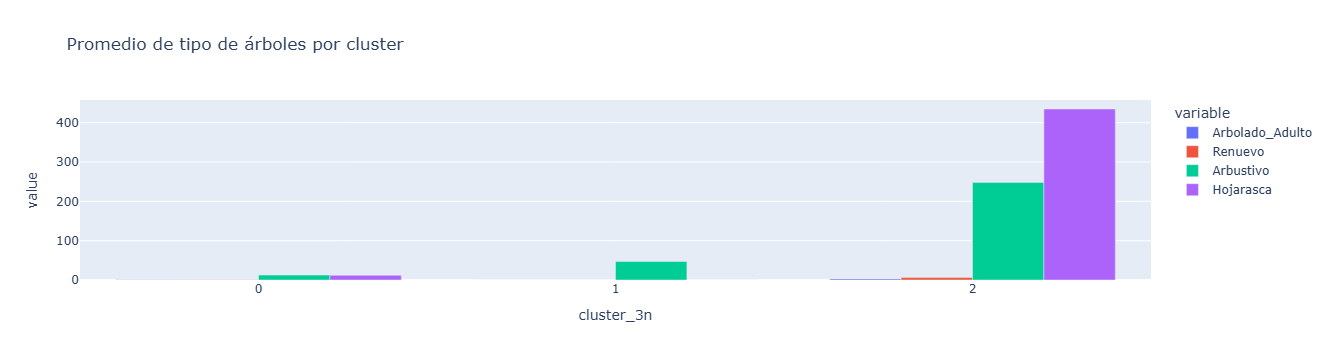

In [170]:
# Resetear índice para que cluster_3n sea columna
perfil_num_reset = perfil_num.reset_index()

# Gráfico de barras agrupadas
fig = px.bar(
    perfil_num_reset,
    x="cluster_3n",
    y=["Arbolado_Adulto", "Renuevo", "Arbustivo", "Hojarasca"],
    barmode="group",
    title="Promedio de tipo de árboles por cluster"
)
fig.show()

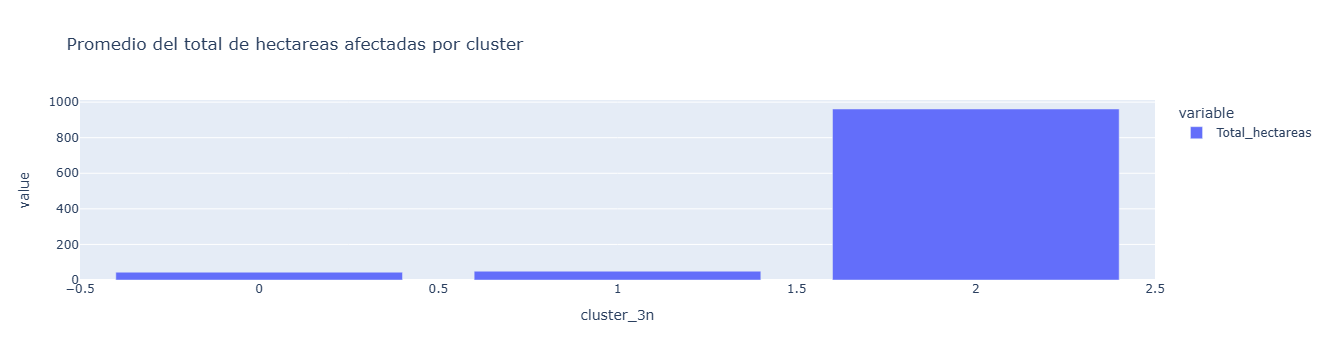

In [171]:
# Resetear índice para que cluster_3n sea columna
perfil_hect_Reset = perfil_num.reset_index()

# Gráfico de barras agrupadas
fig = px.bar(
    perfil_hect_Reset,
    x="cluster_3n",
    y=["Total_hectareas"],
    barmode="group",
    title="Promedio del total de hectareas afectadas por cluster"
)
fig.show()

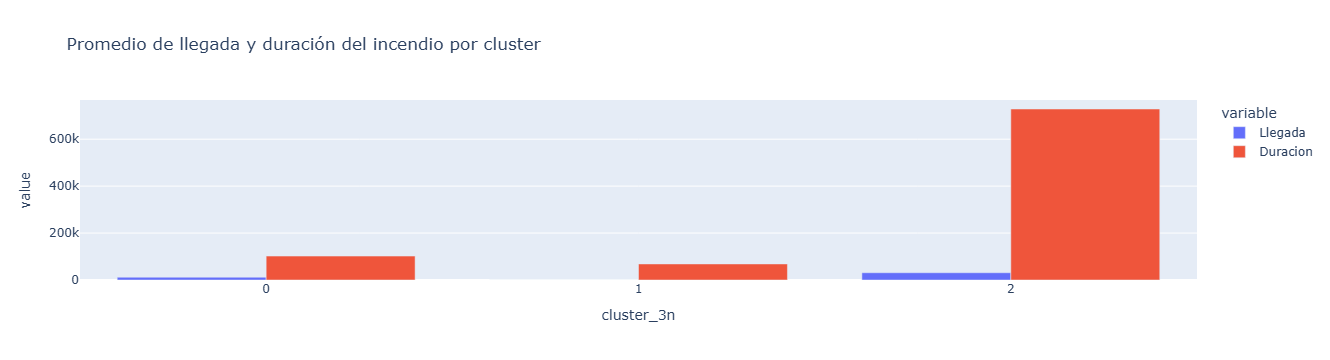

In [172]:
# Resetear índice para que cluster_3n sea columna
perfil_times_reset = perfil_num.reset_index()

# Gráfico de barras agrupadas
fig = px.bar(
    perfil_times_reset,
    x="cluster_3n",
    y=["Llegada", "Duracion"],
    barmode="group",
    title="Promedio de llegada y duración del incendio por cluster"
)
fig.show()

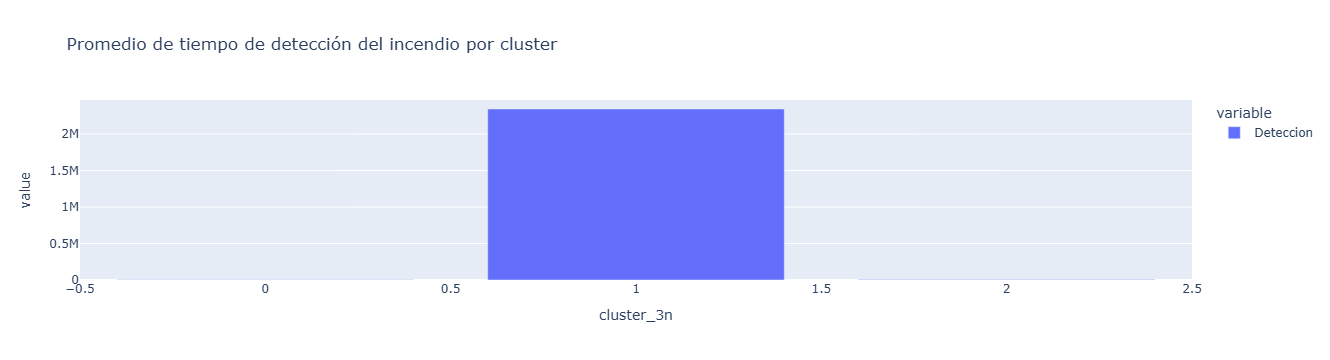

In [173]:
# Resetear índice para que cluster_3n sea columna
perfil_times_reset = perfil_num.reset_index()

# Gráfico de barras agrupadas
fig = px.bar(
    perfil_times_reset,
    x="cluster_3n",
    y=["Deteccion"],
    barmode="group",
    title="Promedio de tiempo de detección del incendio por cluster"
)
fig.show()

<h2 style="color:#9A9786; font-size: 1.2em; font-weight: bold;"> Perfilamiento final </h2>

| Cluster | Nombre corto | Descripción |
|----------|----------|----------|
| 0    | Incendios breves intencionales | Mayormente en centro y occidente, duran 1 día, impacto mínimo (0–5 ha), causados intencionalmente, afectan bosques/selvas con vegetación hojarasca y arbustiva. Promedio: 43 ha. |
| 1    |  Incendios cortos accidentales | En centro y norte, duran 1–3 días, impacto mínimo (0–20 ha) o muy alto (>100 ha), causas accidentales o desconocidas, afectan selvas con vegetación arbustiva. Promedio de 50 ha afectadas. Son los que más tardan en ser detectados  |
| 2    | Incendios prolongados severos  | En centro y occidente, duran 4–7 días, impacto severo (>100 ha), causas desconocidas, afectan bosques/selvas con vegetación variada (hojarasca, arbustiva, renueva, árboles adultos). Promedio: 961 ha. Son los más largos y tardan en ser atendidos. |